[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part6-media-optimization/sec6.2_6.4_mmm_meridian.ipynb)

# Marketing Mix Modeling with Meridian

**Companion notebook for Section 6.2 (Fundamentals — Steps 1–13) and Section 6.4 (Calibration — Steps 14–17) of *Marketing Science in Python*.**

This notebook walks through a complete MMM workflow using Google's [Meridian](https://github.com/google/meridian) library on **synthetic data generated by [PySiMMMulator](https://github.com/RyanAugust/PySiMMMulator)** (see `mmm_data_generation.py`).

1. **Install / import** — bring in TensorFlow, TFP, and Meridian
2. **Data loading** — load synthetic marketing data with known ground-truth ROI
2b. **Data identifiability check** — §6.4 Reliability Checklist applied pre-fit
3. **Build Meridian InputData** — exposure volumes drive saturation, spend drives ROI
4. **Holdout split** — random 25% of weeks for out-of-sample evaluation
5. **Model configuration** — weakly informative ROI prior + funnel-stage adstock/EC
6. **Model training** — Bayesian MMM with adstock and saturation via MCMC (NUTS)
7. **Diagnostics** — convergence checks and prior/posterior shift
8. **Model fit** — in-sample R² and out-of-sample R² from the holdout
9. **Media insights** — ROI, contribution, and response curves
10. **Ground-truth comparison** — compare estimated ROI against the known true values
11. **Budget optimization** — optimal allocation given a fixed total budget
12. **Reallocation table** — channel-level spend deltas the optimizer recommends
13. **Credible interval guardrail** — convert posterior uncertainty into act/hold per channel
14. **Geo-lift → calibrated prior** — turn §6.3's DID estimate into §6.4's `roi_m` prior
15. **Refit with calibrated prior** — apply the calibration and resample
16. **Before / after ROI** — does calibration close the recovery gap for the calibrated channel?
17. **Re-optimize from calibrated model** — does the budget recommendation change?
18. **Scope and limitations** — what this demo proves and what it does not
19. **Persistence** — save both fitted models

Because we use synthetic data with **known ground-truth ROI**, we can validate that Meridian's estimates recover the true channel-level effects — something impossible with real-world observational data.

> **Important:** Meridian applies Hill saturation to `media_cols` (impressions/clicks), not to spend. This correctly models diminishing returns on *exposure volume* while keeping spend as a cost metric for ROI calculation.

## Step 1: Install and Import

Meridian is built on TensorFlow and TensorFlow Probability. The local `marketing-science` conda environment pins all three; in Colab, install `google-meridian` before running.

In [1]:
# Dependencies come from the repo-root environment.yml.
# In Colab, install google-meridian before running this notebook.
import importlib.util

required_modules = ["tensorflow", "tensorflow_probability", "meridian"]
missing = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError(
        "Missing MMM dependencies: " + ", ".join(missing)
        + ". Update the marketing-science environment from environment.yml."
    )
print("MMM dependencies available.")

MMM dependencies available.


In [2]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo root marker, so it needs the repo
# tree present, which the clone provides.)
import sys
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401

import warnings

# Keep Meridian/numpy advisory warnings out of the saved output. They print
# absolute site-packages paths from whichever machine ran the notebook, which
# mean nothing to a reader and must not ship inside a published notebook.
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp

# Disable TF32 on Ampere+ GPUs to improve MCMC numerical stability.
tf.config.experimental.enable_tensor_float_32_execution(False)

from meridian import constants
from meridian.data import data_frame_input_data_builder
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.analysis import analyzer
from meridian.analysis import optimizer
from meridian.analysis import summarizer
from meridian.analysis import visualizer
from meridian.analysis.review import reviewer

In [3]:
# GitHub renders a committed .ipynb without executing JavaScript, so Meridian's
# interactive Altair charts would be invisible there. Outside Colab, render
# Altair output as static PNGs (via vl-convert) so the saved charts are
# readable on GitHub. On Colab, keep the default interactive renderer.
import importlib.util

if "google.colab" not in sys.modules and importlib.util.find_spec("vl_convert"):
    import altair as alt

    alt.renderers.enable("png", scale_factor=2)

## Step 2: Load Synthetic Data

The synthetic data was generated by `mmm_data_generation.py` using PySiMMMulator. The CSV contains both **exposure volumes** (impressions for TV/CTV, OOH, Meta, TikTok; clicks for Google Search) and **spend** for each channel, along with control variables.

In [4]:
# Paths are resolved by the in-repo `msbook` package (installed via
# `pip install -e .` from the repo root — see README), so this works from
# any cwd or notebook subdirectory.
from msbook.data import load_mmm_synthetic
from msbook.paths import DATA_DIR

df = load_mmm_synthetic()
truth_df = pd.read_csv(DATA_DIR / "generated" / "part6" / "sec6.2-mmm" / "mmm_ground_truth_roi.csv")

print(f"Dataset shape: {df.shape}")
print(f"Period: {df['time'].min()} to {df['time'].max()}")
print()
print("Ground-truth ROI per channel:")
print(truth_df.to_string(index=False))
df.head()

Dataset shape: (157, 19)
Period: 2020-12-28 to 2023-12-25

Ground-truth ROI per channel:
      channel  true_roi  true_marginal_roi  true_pullback_roas_8w  adstock_half_life_weeks  adstock_decay  hill_half_saturation
       TV/CTV      4.17             1.8000                 0.8311                      6.0         0.8909          3.191163e+08
          OOH      6.28             3.5000                 2.0496                      6.0         0.8909          1.529842e+09
Google Search      0.35             0.2129                 0.2000                      1.0         0.5000          1.021349e+06
         Meta      3.75             2.8000                 2.3044                      3.0         0.7937          1.505579e+09
       TikTok      3.01             0.8000                 0.5112                      3.0         0.7937          2.281184e+08


,time,geo,tv_ctv_impressions,ooh_impressions,meta_impressions,tiktok_impressions,google_clicks,tv_ctv_spend,ooh_spend,meta_spend,tiktok_spend,google_spend,sales,seas_sin52,seas_cos52,hldy_thanksgiving,hldy_christmas,trend,trend_sq
0,2020-12-28,national,3.245328e+07,0.0,1.246514e+08,7.183281e+07,298874.145698,381810.400075,0.0,9.479498e+05,402127.527178,740172.377132,1.981909e+07,-0.038696,0.999251,0,1,0.0,0.0
1,2021-01-04,national,7.088608e+07,0.0,2.228168e+08,1.531309e+08,305467.264286,836368.932308,0.0,1.777590e+06,882131.255673,767963.838880,3.525837e+07,0.068755,0.997634,0,0,1.0,1.0
2,2021-01-11,national,7.049427e+07,0.0,2.148787e+08,1.506682e+08,334118.696548,848207.495389,0.0,1.612442e+06,772334.178448,775939.051549,3.670446e+07,0.188099,0.982150,0,0,2.0,4.0
3,2021-01-18,national,6.291244e+07,0.0,2.039079e+08,1.378797e+08,319566.707117,783615.601713,0.0,1.618560e+06,851137.518439,775985.250968,3.914444e+07,0.304719,0.952442,0,0,3.0,9.0
4,2021-01-25,national,6.422619e+07,0.0,2.223922e+08,1.249268e+08,294203.791090,742156.943928,0.0,1.683244e+06,755420.784171,776506.200269,3.921875e+07,0.416926,0.908940,0,0,4.0,16.0


## Step 2b: Data Identifiability Check

Before fitting, Section 6.4's *Reliability Checklist* names four pre-fit failure modes:

1. **Enough history** — short panels make adstock, trend, and saturation hard to separate; this notebook requires ~80 weekly observations as its practical floor.
2. **Real variation in spend** — channels with constant weekly spend give the model no signal.
3. **Correlated media flights** — when channels move in lockstep, the model can't separate their effects.
4. **A media signal comparable to the unexplained noise** — the one that is easiest to miss. Adstock and saturation smooth the media contribution, so it can end up moving sales less from week to week than whatever the control variables fail to explain. The lower that ratio, the more the coefficients come from the prior rather than the data. Measure both sides after projecting out the controls: the part of media that moves with trend and seasonality is not what identifies anything.

A practitioner would walk away from any MMM that fails the first three. The fourth is a dial rather than a gate, and this dataset sits just under 1 on it deliberately: that is why the weak ROI prior is load-bearing, and why one channel comes back unidentified. The first three thresholds match `mmm_data_generation.py`'s identifiability QC.

In [5]:
spend_cols = ["tv_ctv_spend", "ooh_spend", "google_spend", "meta_spend", "tiktok_spend"]
spend_df = df[spend_cols].copy()
spend_df.columns = ["TV/CTV", "OOH", "Google Search", "Meta", "TikTok"]

# (1) History length.
n_weeks = len(df)
print(f"(1) History: {n_weeks} weekly observations "
      f"({'PASS' if n_weeks >= 80 else 'FAIL'} — need ≥ 80)")

# (2) Spend variation: share-of-budget standard deviation per channel during weeks the channel was on.
total_spend = spend_df.sum(axis=1).replace(0, np.nan)
shares = spend_df.div(total_spend, axis=0).fillna(0)
share_std = {col: float(shares[col][spend_df[col] > 0].std()) for col in spend_df.columns}
off_rate = {col: float((spend_df[col] == 0).mean()) for col in spend_df.columns}

variation = pd.DataFrame({
    "OFF rate (weeks off)":  off_rate,
    "Share std (when on)":   share_std,
})
print()
print("(2) Per-channel spend variation:")
print(variation.to_string(float_format=lambda x: f"{x:.3f}"))
worst_off_rate = max(off_rate.values())
worst_share_std = min(share_std.values())
print(f"  Worst OFF rate (high is bad past ~25%): {worst_off_rate:.1%} — "
      f"{'PASS' if worst_off_rate <= 0.25 else 'WARN'}")
print(f"  Lowest share std (low = no variation): {worst_share_std:.3f} — "
      f"{'PASS' if worst_share_std >= 0.05 else 'WARN'}")

# (3) Channel correlation matrix.
corr = spend_df.corr().abs()
# Diagonal is 1.0; look at off-diagonal maximum.
np.fill_diagonal(corr.values, 0.0)
print()
print("(3) Absolute channel-spend correlation matrix:")
print(corr.to_string(float_format=lambda x: f"{x:.2f}"))
max_corr = float(corr.values.max())
print(f"  Max off-diagonal |corr| (high = collinearity risk past ~0.85): {max_corr:.2f} — "
      f"{'PASS' if max_corr <= 0.85 else 'FAIL'}")

# (4) Signal to noise: is the media signal bigger than the unexplained noise?
# Controls explain the demand that media did not create. Whatever is left over is
# the room media has to work in. Compare how much of that leftover the media
# series can explain against how much stays unexplained even with media in the
# model. A ratio below 1 means media moves sales less than the noise does, and
# the channel coefficients will absorb baseline movement instead.
#
# The comparison has to use the carryover you plan to model. Raw weekly spend
# understates what media can explain, because adstock is exactly the transform
# that turns lumpy spend into the smooth series sales actually respond to: on
# this dataset raw spend scores 0.55 and would fail a dataset that is fine.
HALF_LIFE_WEEKS = {"TV/CTV": 6, "OOH": 6, "Google Search": 1, "Meta": 3, "TikTok": 3}
exposure_cols_qc = [
    "tv_ctv_impressions", "ooh_impressions", "google_clicks",
    "meta_impressions", "tiktok_impressions",
]


def _adstock(series, decay, max_lag=12):
    """Meridian's own definition: sum_i x_{t-i} * decay**i."""
    out = np.zeros(len(series), dtype=float)
    for lag in range(max_lag + 1):
        out[lag:] += (decay ** lag) * (series if lag == 0 else series[:-lag])
    return out


def _residual(design, target):
    coefficients, *_ = np.linalg.lstsq(design, target, rcond=None)
    return target - design @ coefficients


sales = df["sales"].to_numpy(float)
control_matrix = np.column_stack([np.ones(len(df)), df[[
    "seas_sin52", "seas_cos52", "hldy_thanksgiving", "hldy_christmas", "trend", "trend_sq",
]].to_numpy(float)])
media_basis = np.column_stack([
    _adstock(df[col].to_numpy(float), 0.5 ** (1.0 / HALF_LIFE_WEEKS[channel]))
    for channel, col in zip(spend_df.columns, exposure_cols_qc)
])

def signal_to_noise(control_design, media_design, target):
    """Media movement the controls cannot account for, over movement nothing can.

    Both quantities are measured after the controls are projected out, because
    the part of media that moves with trend and seasonality is not what
    identifies the coefficient. Comparing a raw signal with a residualised noise
    flatters the ratio.
    """
    residual_controls = _residual(control_design, target)
    residual_full = _residual(np.column_stack([control_design, media_design]), target)
    signal = float(np.sqrt(max(residual_controls.var() - residual_full.var(), 0.0)))
    noise = float(residual_full.std())
    return signal, noise, signal / noise


def known_truth_signal_to_noise(control_design, media_contribution, target):
    """The same ratio computed from the true contribution, which only a synthetic
    panel can do. It is the authoritative one: the empirical estimate above fits
    five coefficients of its own, so it explains some of the noise and reads high."""
    signal = _residual(control_design, media_contribution)
    noise = _residual(control_design, target - media_contribution)
    return float(signal.std()), float(noise.std()), float(signal.std() / noise.std())


media_signal_sd, noise_sd, signal_to_noise_ratio = signal_to_noise(
    control_matrix, media_basis, sales
)
print()
print("(4) Media signal vs. unexplained noise:")
print(f"  Weekly sales movement media explains beyond the controls: ${media_signal_sd:,.0f}")
print(f"  Weekly sales movement nothing explains:                   ${noise_sd:,.0f}")
print(f"  Estimated signal-to-noise ratio: {signal_to_noise_ratio:.2f}")

# Because this dataset is synthetic we can compute the same ratio from the true
# response curves, which a real project never can. The generator solves each
# channel's curve to hit a chosen average and marginal ROI, so the true weekly
# media contribution is reconstructable from the ground-truth table.
truth_by_channel = truth_df.set_index("channel")
true_contribution = np.zeros(len(df), dtype=float)
for channel, exposure_col, spend_col in zip(spend_df.columns, exposure_cols_qc, spend_cols):
    row = truth_by_channel.loc[channel]
    adstocked = _adstock(df[exposure_col].to_numpy(float), float(row["adstock_decay"]))
    shape = adstocked / (adstocked + float(row["hill_half_saturation"]))
    true_contribution += float(row["true_roi"]) * df[spend_col].sum() / shape.sum() * shape

true_signal_sd, true_noise_sd, true_ratio = known_truth_signal_to_noise(
    control_matrix, true_contribution, sales
)
print(f"  Same ratio from the known truth: {true_ratio:.2f} "
      f"(media is {true_contribution.sum() / sales.sum():.1%} of sales)")
print()
print("  Read it as a dial, not a gate. Below about 1 the media coefficients lean")
print("  on their priors rather than on the data, which is where this panel sits:")
print("  the model recovers most channels but over-attributes, and Google Search,")
print("  the quietest of the five, is not identified at all. That is the demo's")
print("  premise, and Sections 6.3 and 6.4 are what you do about it.")

(1) History: 157 weekly observations (PASS — need ≥ 80)

(2) Per-channel spend variation:
               OFF rate (weeks off)  Share std (when on)
TV/CTV                        0.070                0.054
OOH                           0.102                0.081
Google Search                 0.000                0.027
Meta                          0.178                0.086
TikTok                        0.051                0.083
  Worst OFF rate (high is bad past ~25%): 17.8% — PASS
  Lowest share std (low = no variation): 0.027 — WARN

(3) Absolute channel-spend correlation matrix:
               TV/CTV  OOH  Google Search  Meta  TikTok
TV/CTV           0.00 0.36           0.09  0.20    0.25
OOH              0.36 0.00           0.06  0.18    0.26
Google Search    0.09 0.06           0.00  0.23    0.27
Meta             0.20 0.18           0.23  0.00    0.55
TikTok           0.25 0.26           0.27  0.55    0.00
  Max off-diagonal |corr| (high = collinearity risk past ~0.85): 0.55 — PAS

## Step 3: Build Meridian InputData

Meridian separates exposure volume from spend. `media_cols` (impressions/clicks) drive the Hill saturation curve; `media_spend_cols` is the cost basis for ROI. Controls handle seasonality, holidays, and trend.

In [6]:
channels = ["TV/CTV", "OOH", "Google Search", "Meta", "TikTok"]

media_cols = [
    "tv_ctv_impressions", "ooh_impressions", "google_clicks",
    "meta_impressions", "tiktok_impressions",
]
media_spend_cols = [
    "tv_ctv_spend", "ooh_spend", "google_spend",
    "meta_spend", "tiktok_spend",
]
control_cols = [
    "seas_sin52", "seas_cos52",
    "hldy_thanksgiving", "hldy_christmas",
    "trend", "trend_sq",
]

assert len(media_cols) == len(media_spend_cols) == len(channels), "List length mismatch"

builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
    kpi_type="revenue",
    default_kpi_column="sales",
    default_time_column="time",
    default_geo_column="geo",
)
data = (
    builder
    .with_kpi(df)
    .with_media(df, media_cols=media_cols, media_spend_cols=media_spend_cols, media_channels=channels)
    .with_controls(df, control_cols=control_cols)
    .build()
)

## Step 4: Holdout Split for Out-of-Sample Validation

A strong in-sample fit on its own is not evidence that the model generalizes. We mark 25% of weeks as **holdout** — Meridian keeps the media in those weeks (so adstock carry-over is preserved) but excludes the KPI from the training likelihood. `predictive_accuracy_table()` will then report Train and Test R² separately.

We use a **random week-level sample** rather than a trailing block. With trend + seasonality, a trailing-block holdout asks the model to extrapolate beyond its training window, which dramatically depresses out-of-sample R² for reasons that have nothing to do with media measurement. A random week-level holdout interleaves train and test weeks so out-of-sample R² reflects the model's ability to interpolate within the observed regime — the more useful generalization check for MMM.

For a national model `holdout_id` is a 1-D boolean array of shape `(n_times,)`. For a geo-level model it is `(n_geos, n_times)`.

In [7]:
n_times = df["time"].nunique()
holdout_frac = 0.25
n_holdout = int(round(n_times * holdout_frac))

rng = np.random.default_rng(20260520)  # deterministic
holdout_idx = rng.choice(n_times, size=n_holdout, replace=False)
holdout_id = np.zeros(n_times, dtype=bool)
holdout_id[holdout_idx] = True

print(f"Total weeks: {n_times}")
print(f"Train weeks: {n_times - n_holdout}  ({1 - holdout_frac:.0%})")
print(f"Test  weeks: {n_holdout}  ({holdout_frac:.0%})")
print(f"Test weeks span: indices {holdout_idx.min()} to {holdout_idx.max()}  (random scatter)")

Total weeks: 157
Train weeks: 118  (75%)
Test  weeks: 39  (25%)
Test weeks span: indices 3 to 155  (random scatter)


## Step 5: Model Configuration with Weakly Informative ROI Prior

Meridian separates model specification into two components:

- **PriorDistribution** — prior beliefs about parameters (ROI, adstock decay, saturation)
- **ModelSpec** — structural choices (max lag, prior type, adstock form)

We use a **weakly informative ROI prior** for every channel: `roi_m ~ LogNormal(0.2, 0.9)`. This matches the structure Section 6.4 of the book uses for uncalibrated channels (median ROAS ≈ 1.2, 90% prior interval ≈ 0.28–5.4) — only channels with experimental evidence (e.g. a geo-lift result) get a tighter, channel-specific prior in production.

For **adstock decay (`alpha_m`)** we do encode channel-specific expectations by funnel stage, because carryover is a property of the channel that a media team knows before fitting.

| Funnel | Channels | Adstock half-life |
|--------|----------|-------------------|
| Upper  | TV/CTV, OOH | 6 weeks |
| Mid    | Meta, TikTok | 3 weeks |
| Lower  | Google Search | 1 week |

**Saturation gets no funnel structure.** One channel-independent prior on `ec_m` covers all five, and the data decides where each curve bends. Two details make that prior look unusual next to Meridian's default of `TruncatedNormal(0.8, 0.8, 0.1, 10)`. First, Meridian's adstock is *not* normalized: it sums `x_{t-i} * alpha^i` without dividing by the weights, so a channel with a six-week half-life carries an adstocked value about seven times its weekly median, and its half-saturation point has to live on that larger scale. Second, this dataset's true half-saturation values run from roughly 3 to 14 in those units, which the default prior's upper bound of 10 would exclude outright. `TruncatedNormal(5, 2, 0.1, 30)` covers the range without naming a channel.

In [8]:
DTYPE = tf.float32

channel_funnel = {
    "TV/CTV": "upper",
    "OOH": "upper",
    "Google Search": "lower",
    "Meta": "mid",
    "TikTok": "mid",
}

half_life_weeks = {"upper": 6, "mid": 3, "lower": 1}

alpha_loc = tf.constant(
    [0.5 ** (1.0 / half_life_weeks[channel_funnel[ch]]) for ch in channels],
    dtype=DTYPE,
)

prior = prior_distribution.PriorDistribution(
    # Weakly informative ROI prior — same as §6.4's uncalibrated channels.
    roi_m=tfp.distributions.LogNormal(
        loc=tf.constant(0.2, dtype=DTYPE),
        scale=tf.constant(0.9, dtype=DTYPE),
        name=constants.ROI_M,
    ),
    # Funnel-stage centers for adstock decay. These are the half-lives the media
    # team would state before seeing the model, and the generator plants them.
    alpha_m=tfp.distributions.TruncatedNormal(
        loc=alpha_loc,
        scale=tf.constant(0.1, dtype=DTYPE),
        low=tf.constant(0.0, dtype=DTYPE),
        high=tf.constant(1.0, dtype=DTYPE),
        name=constants.ALPHA_M,
    ),
    # One saturation prior for every channel. Wide enough to hold the range this
    # panel's curves actually occupy, and deliberately channel-independent: the
    # data identifies where each curve bends, so there is nothing to encode here.
    ec_m=tfp.distributions.TruncatedNormal(
        loc=tf.constant(5.0, dtype=DTYPE),
        scale=tf.constant(2.0, dtype=DTYPE),
        low=tf.constant(0.1, dtype=DTYPE),
        high=tf.constant(30.0, dtype=DTYPE),
        name=constants.EC_M,
    ),
)

model_spec = spec.ModelSpec(
    prior=prior,
    media_prior_type="roi",
    max_lag=12,
    adstock_decay_spec="geometric",
    holdout_id=holdout_id,
)

print("Active prior:")
print("  roi_m   : LogNormal(loc=0.20, scale=0.90)   [weakly informative, all channels]")
print(f"  alpha_m : TruncatedNormal centered on funnel-stage half-lives "
      f"({alpha_loc.numpy().round(2).tolist()})")
print("  ec_m    : TruncatedNormal(5.0, 2.0) on [0.1, 30]  [one prior, all channels]")
print(f"Prior ROAS median = {np.exp(0.2):.2f}; "
      f"90% interval ≈ [{np.exp(0.2 - 1.645*0.9):.2f}, "
      f"{np.exp(0.2 + 1.645*0.9):.2f}]")

Active prior:
  roi_m   : LogNormal(loc=0.20, scale=0.90)   [weakly informative, all channels]
  alpha_m : TruncatedNormal centered on funnel-stage half-lives ([0.8899999856948853, 0.8899999856948853, 0.5, 0.7900000214576721, 0.7900000214576721])
  ec_m    : TruncatedNormal(5.0, 2.0) on [0.1, 30]  [one prior, all channels]
Prior ROAS median = 1.22; 90% interval ≈ [0.28, 5.37]


## Step 6: Model Training

Meridian fits the model via MCMC using the No-U-Turn Sampler (NUTS). For CPU execution we keep the budget modest — 4 chains × 1,000 kept samples = 4,000 posterior draws — which is enough to assess R-hat and recover ROI signs on this 157-week dataset. Production runs typically use 10 chains × 2,000 keep.

We first draw from the prior (for prior predictive checks), then sample the posterior.

In [9]:
SEED = 105

mmm = model.Meridian(input_data=data, model_spec=model_spec)

# Prior predictive check
mmm.sample_prior(500)

# Posterior sampling via NUTS MCMC
mmm.sample_posterior(
    n_chains=4,
    n_adapt=500,
    n_burnin=500,
    n_keep=1000,
    seed=SEED,
)

I0000 00:00:1788354822.439330 13829126 service.cc:152] XLA service 0x600001312300 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788354822.439353 13829126 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1788354822.485751 13829126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-09-02 09:14:15.079352: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-09-02 09:14:16.205073: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


## Step 7: Diagnostics

`ModelReviewer` runs the full battery (convergence, baseline validation, goodness of fit, prior-posterior shift). `ModelDiagnostics` produces the per-parameter R-hat plot — values should be close to 1.0.

In [10]:
# Automated model quality checks
review_summary = reviewer.ModelReviewer(mmm).run()
print(review_summary.summary_message)

Passed: No major quality issues were identified.


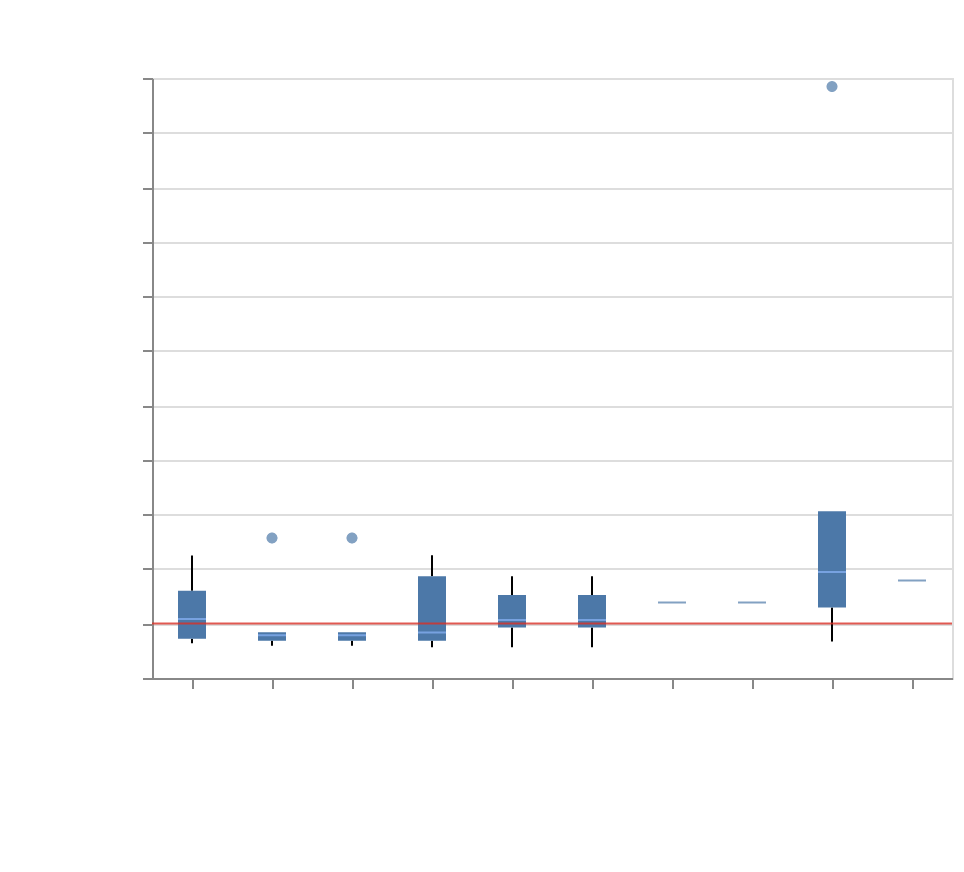

In [11]:
# R-hat values should be close to 1.0 for all parameters
diagnostics = visualizer.ModelDiagnostics(mmm)
diagnostics.plot_rhat_boxplot()

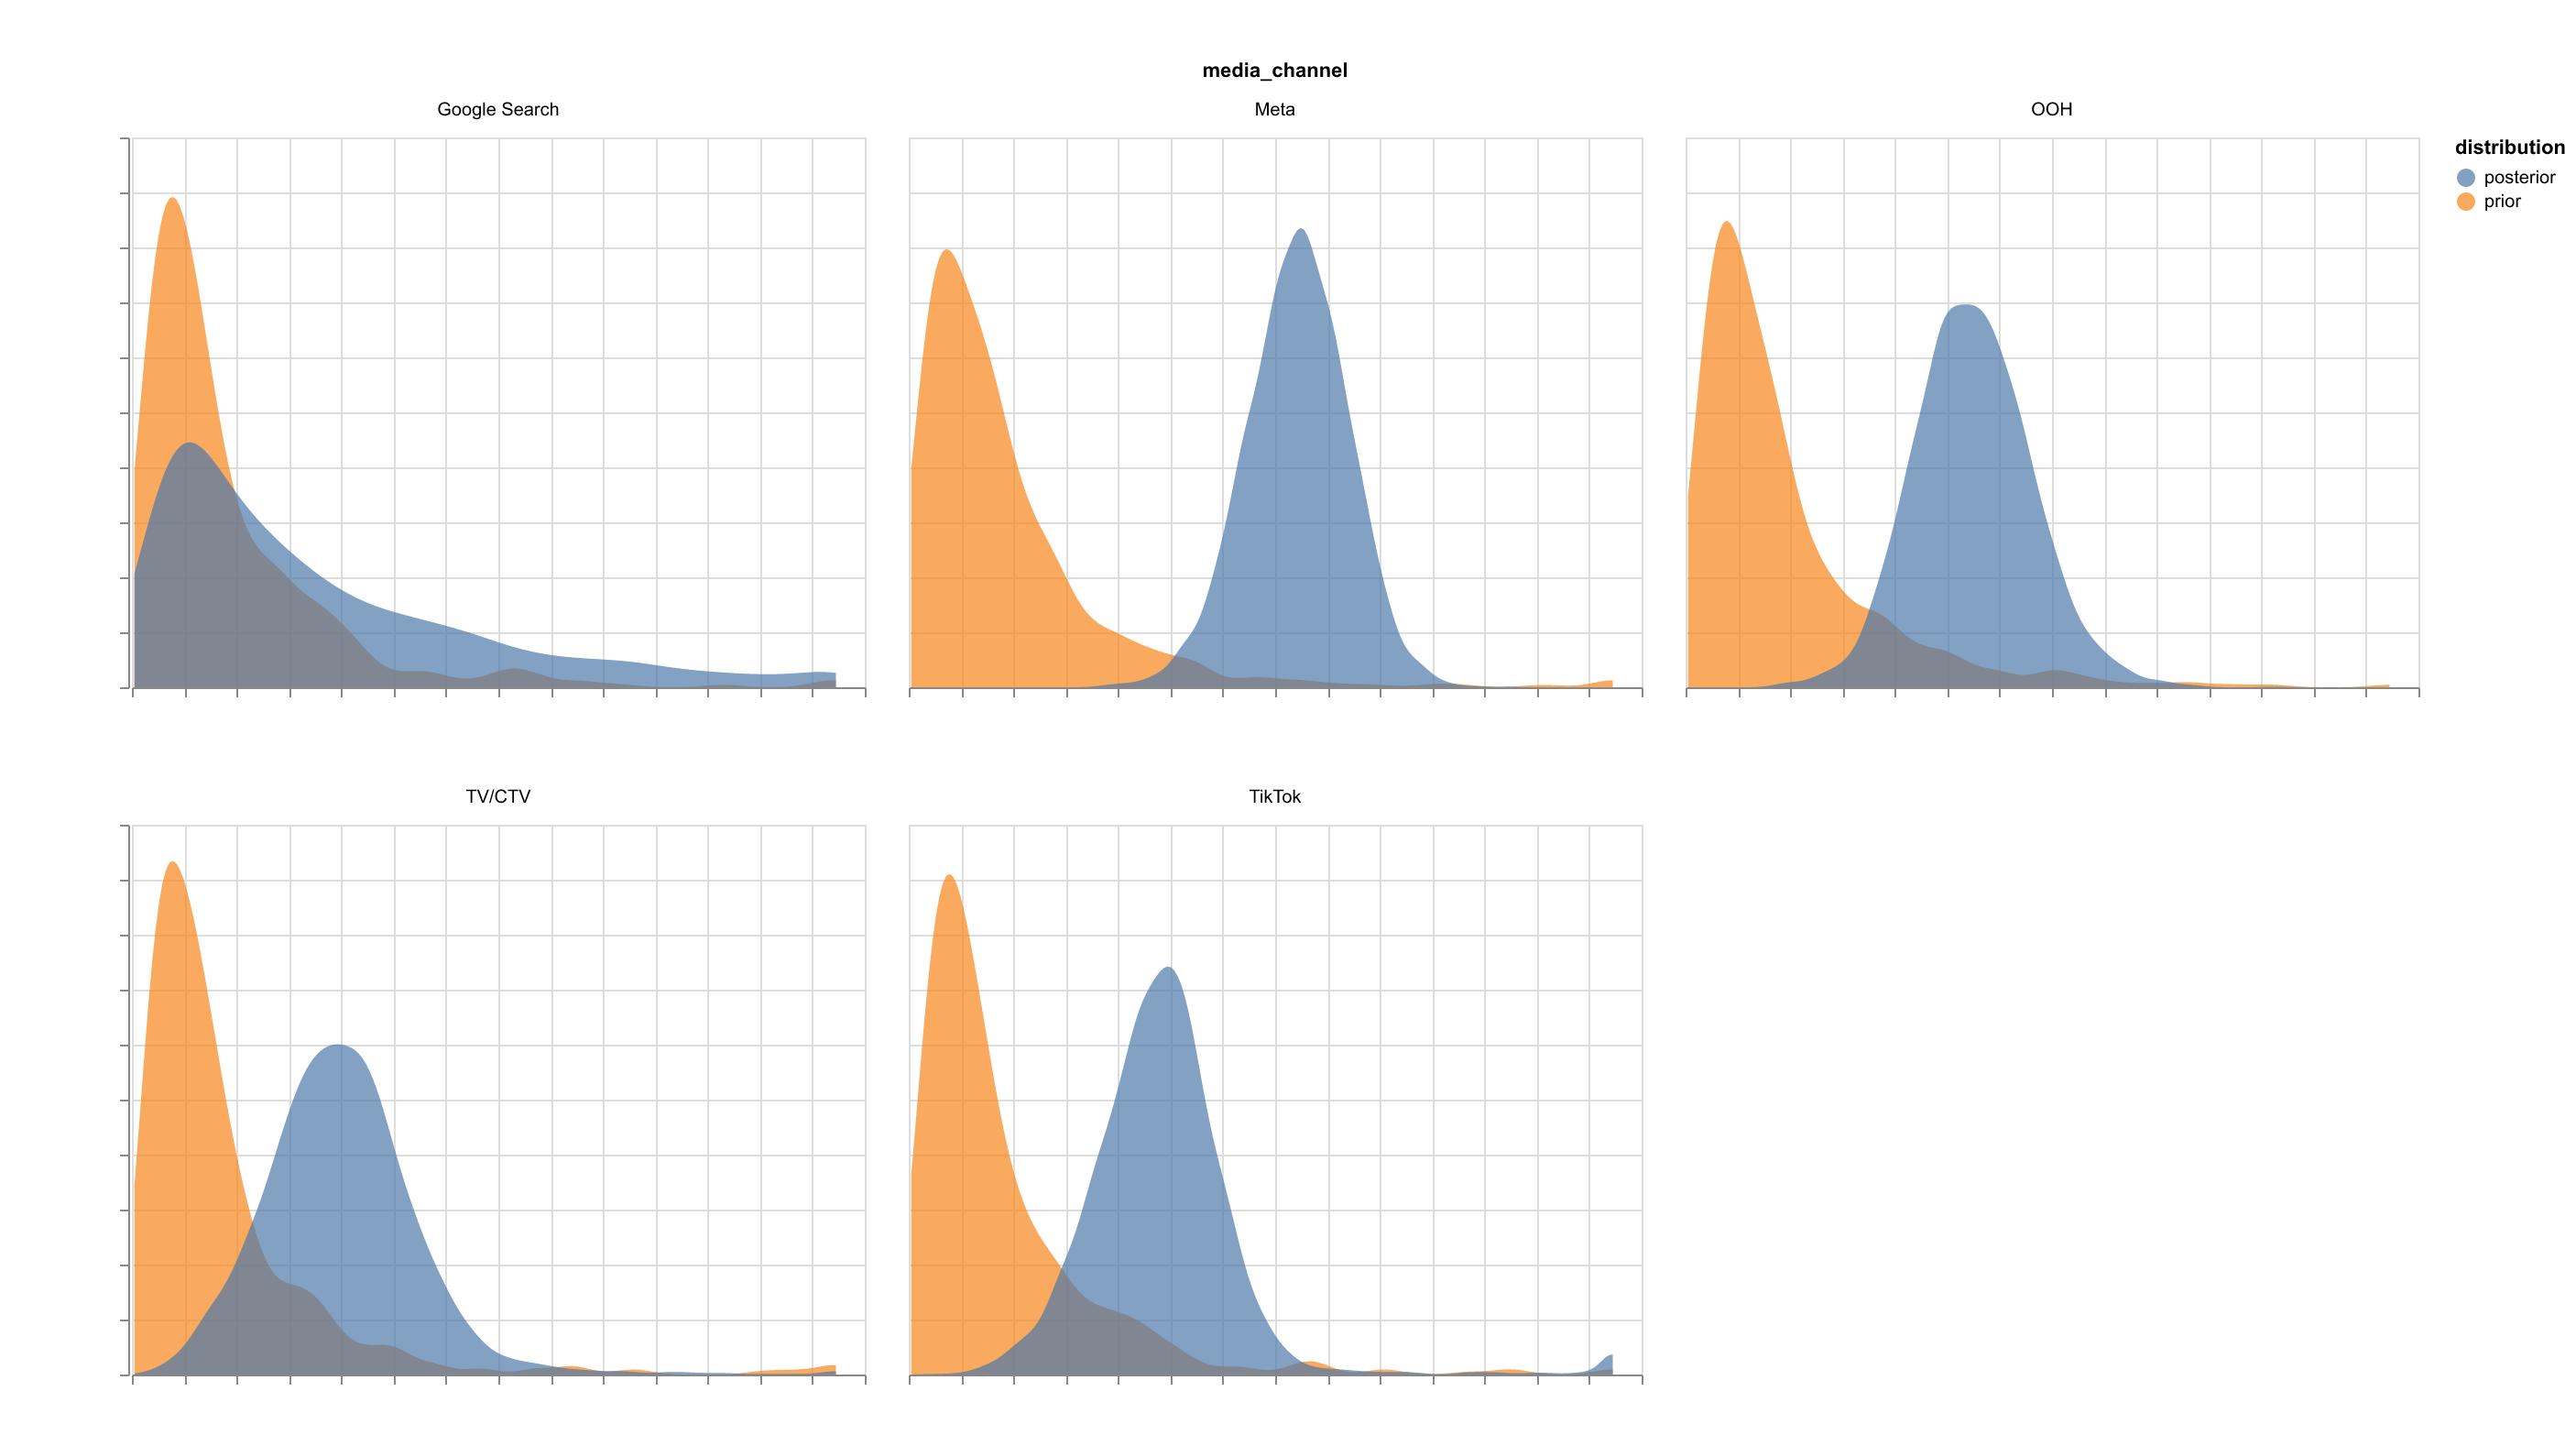

In [12]:
# Compare prior and posterior — data should update the priors meaningfully
diagnostics.plot_prior_and_posterior_distribution()

## Step 8: In-Sample and Out-of-Sample Model Fit

Because we set `holdout_id`, `predictive_accuracy_table()` reports R², MAPE, and wMAPE separately for the Train period, the Test (holdout) period, and the full series. For MMM a healthy gap between in-sample and out-of-sample R² is expected; an out-of-sample R² in the 0.6–0.7 range is typical and acceptable.

In [13]:
accuracy_table = diagnostics.predictive_accuracy_table()
print(accuracy_table.to_string(index=False))

# Pull the headline R² numbers into named variables for downstream reference.
def _r2(table, eval_set):
    rows = table[(table["metric"] == "R_Squared") & (table["evaluation_set"] == eval_set)]
    if rows.empty:
        return float("nan")
    return float(rows["value"].iloc[0])

r2_train = _r2(accuracy_table, "Train")
r2_test  = _r2(accuracy_table, "Test")
r2_all   = _r2(accuracy_table, "All Data")
print(f"\nIn-sample (Train) R² : {r2_train:.3f}")
print(f"Out-of-sample (Test) R² : {r2_test:.3f}")
print(f"Full-series R² : {r2_all:.3f}")

   metric geo_granularity evaluation_set    value
R_Squared        national          Train 0.971991
R_Squared        national           Test 0.967357
R_Squared        national       All Data 0.970780
     MAPE        national          Train 0.021048
     MAPE        national           Test 0.022356
     MAPE        national       All Data 0.021373
    wMAPE        national          Train 0.019406
    wMAPE        national           Test 0.022075
    wMAPE        national       All Data 0.020063

In-sample (Train) R² : 0.972
Out-of-sample (Test) R² : 0.967
Full-series R² : 0.971


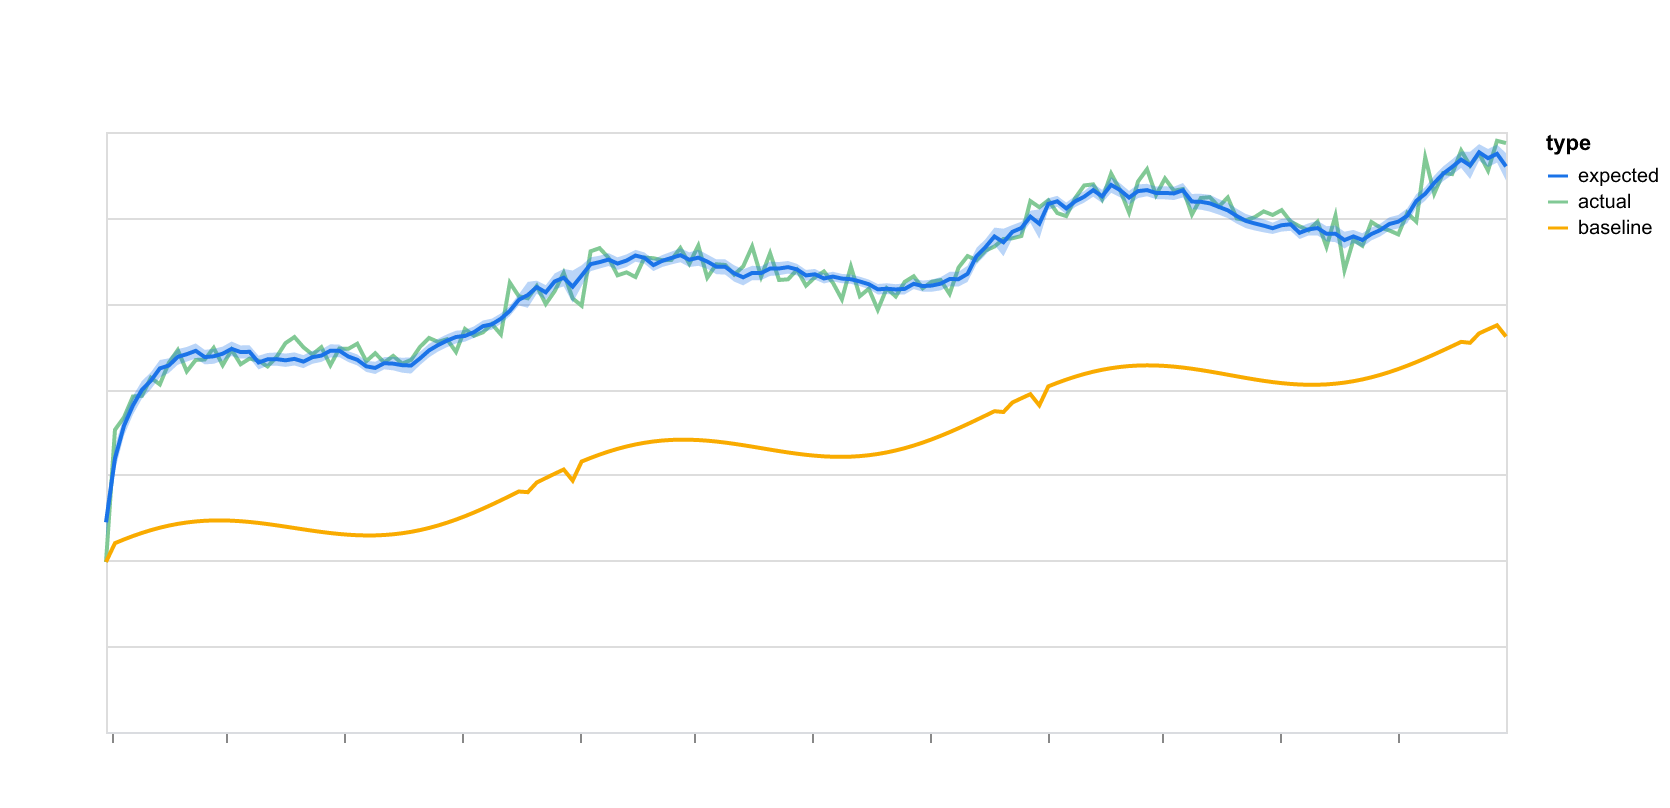

In [14]:
model_fit_viz = visualizer.ModelFit(mmm)
model_fit_viz.plot_model_fit()

## Step 9: Media Insights

Extract the key business outputs: ROI estimates with credible intervals, channel contribution over time, and response curves showing diminishing returns.

In [15]:
# Comprehensive summary: spend, contribution, ROI, mROI per channel
media_summary = visualizer.MediaSummary(mmm)
media_summary.summary_table()

,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,TV/CTV,prior,"9,453,120,512",13.1%,"$111,821,088",18%,$12,"$198,857,648 ($32,317,182, $551,281,920)","2.0% (0.3%, 5.6%)","1.8 (0.3, 4.9)","0.02 (0.00, 0.06)","1.4 (0.2, 3.6)","$0.8 ($0.2, $3.5)"
1,TV/CTV,posterior,"9,453,120,512",13.1%,"$111,821,088",18%,$12,"$447,011,552 ($201,707,520, $700,340,992)","5.3% (2.4%, 8.4%)","4.0 (1.8, 6.3)","0.05 (0.02, 0.07)","3.1 (1.5, 4.7)","$0.3 ($0.2, $0.6)"
2,OOH,prior,"25,210,552,320",34.9%,"$124,379,232",20%,$5,"$233,703,104 ($35,065,180, $660,520,768)","2.4% (0.4%, 6.7%)","1.9 (0.3, 5.3)","0.01 (0.00, 0.03)","1.5 (0.2, 4.3)","$0.8 ($0.2, $3.5)"
3,OOH,posterior,"25,210,552,320",34.9%,"$124,379,232",20%,$5,"$683,132,608 ($464,682,080, $915,021,888)","8.2% (5.5%, 10.9%)","5.5 (3.7, 7.4)","0.03 (0.02, 0.04)","4.3 (2.9, 5.6)","$0.2 ($0.1, $0.3)"
4,Google Search,prior,"51,346,612",0.1%,"$127,134,848",21%,"$2,476","$229,265,344 ($32,760,340, $670,191,552)","2.3% (0.3%, 6.8%)","1.8 (0.3, 5.3)","4.47 (0.64, 13.05)","1.5 (0.2, 4.2)","$0.8 ($0.2, $3.9)"
5,Google Search,posterior,"51,346,612",0.1%,"$127,134,848",21%,"$2,476","$449,323,808 ($50,114,636, $1,308,483,200)","5.4% (0.6%, 15.6%)","3.5 (0.4, 10.3)","8.75 (0.98, 25.48)","2.8 (0.3, 8.3)","$0.4 ($0.1, $2.5)"
6,Meta,prior,"14,574,426,112",20.2%,"$115,230,176",19%,$8,"$207,505,088 ($28,347,720, $581,561,920)","2.1% (0.3%, 5.9%)","1.8 (0.2, 5.0)","0.01 (0.00, 0.04)","1.4 (0.2, 4.0)","$0.8 ($0.2, $4.1)"
7,Meta,posterior,"14,574,426,112",20.2%,"$115,230,176",19%,$8,"$854,999,552 ($668,355,392, $1,033,623,424)","10.2% (8.0%, 12.3%)","7.4 (5.8, 9.0)","0.06 (0.05, 0.07)","6.0 (4.6, 7.2)","$0.1 ($0.1, $0.2)"
8,TikTok,prior,"23,028,600,832",31.8%,"$136,095,120",22%,$6,"$240,122,048 ($38,003,208, $651,794,688)","2.4% (0.4%, 6.6%)","1.8 (0.3, 4.8)","0.01 (0.00, 0.03)","1.4 (0.2, 3.9)","$0.8 ($0.2, $3.6)"
9,TikTok,posterior,"23,028,600,832",31.8%,"$136,095,120",22%,$6,"$663,111,360 ($388,376,032, $907,595,328)","7.9% (4.6%, 10.8%)","4.9 (2.9, 6.7)","0.03 (0.02, 0.04)","3.6 (2.1, 5.0)","$0.2 ($0.1, $0.4)"


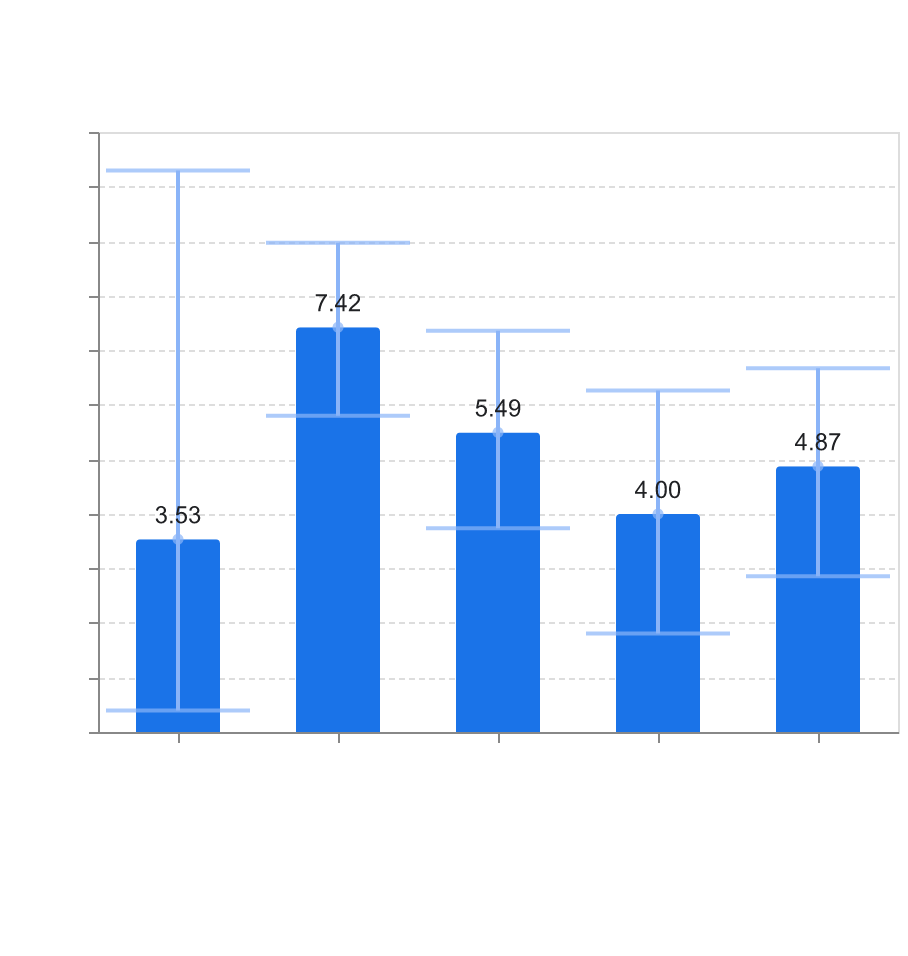

In [16]:
# ROI estimates with credible intervals
media_summary.plot_roi_bar_chart(include_ci=True)

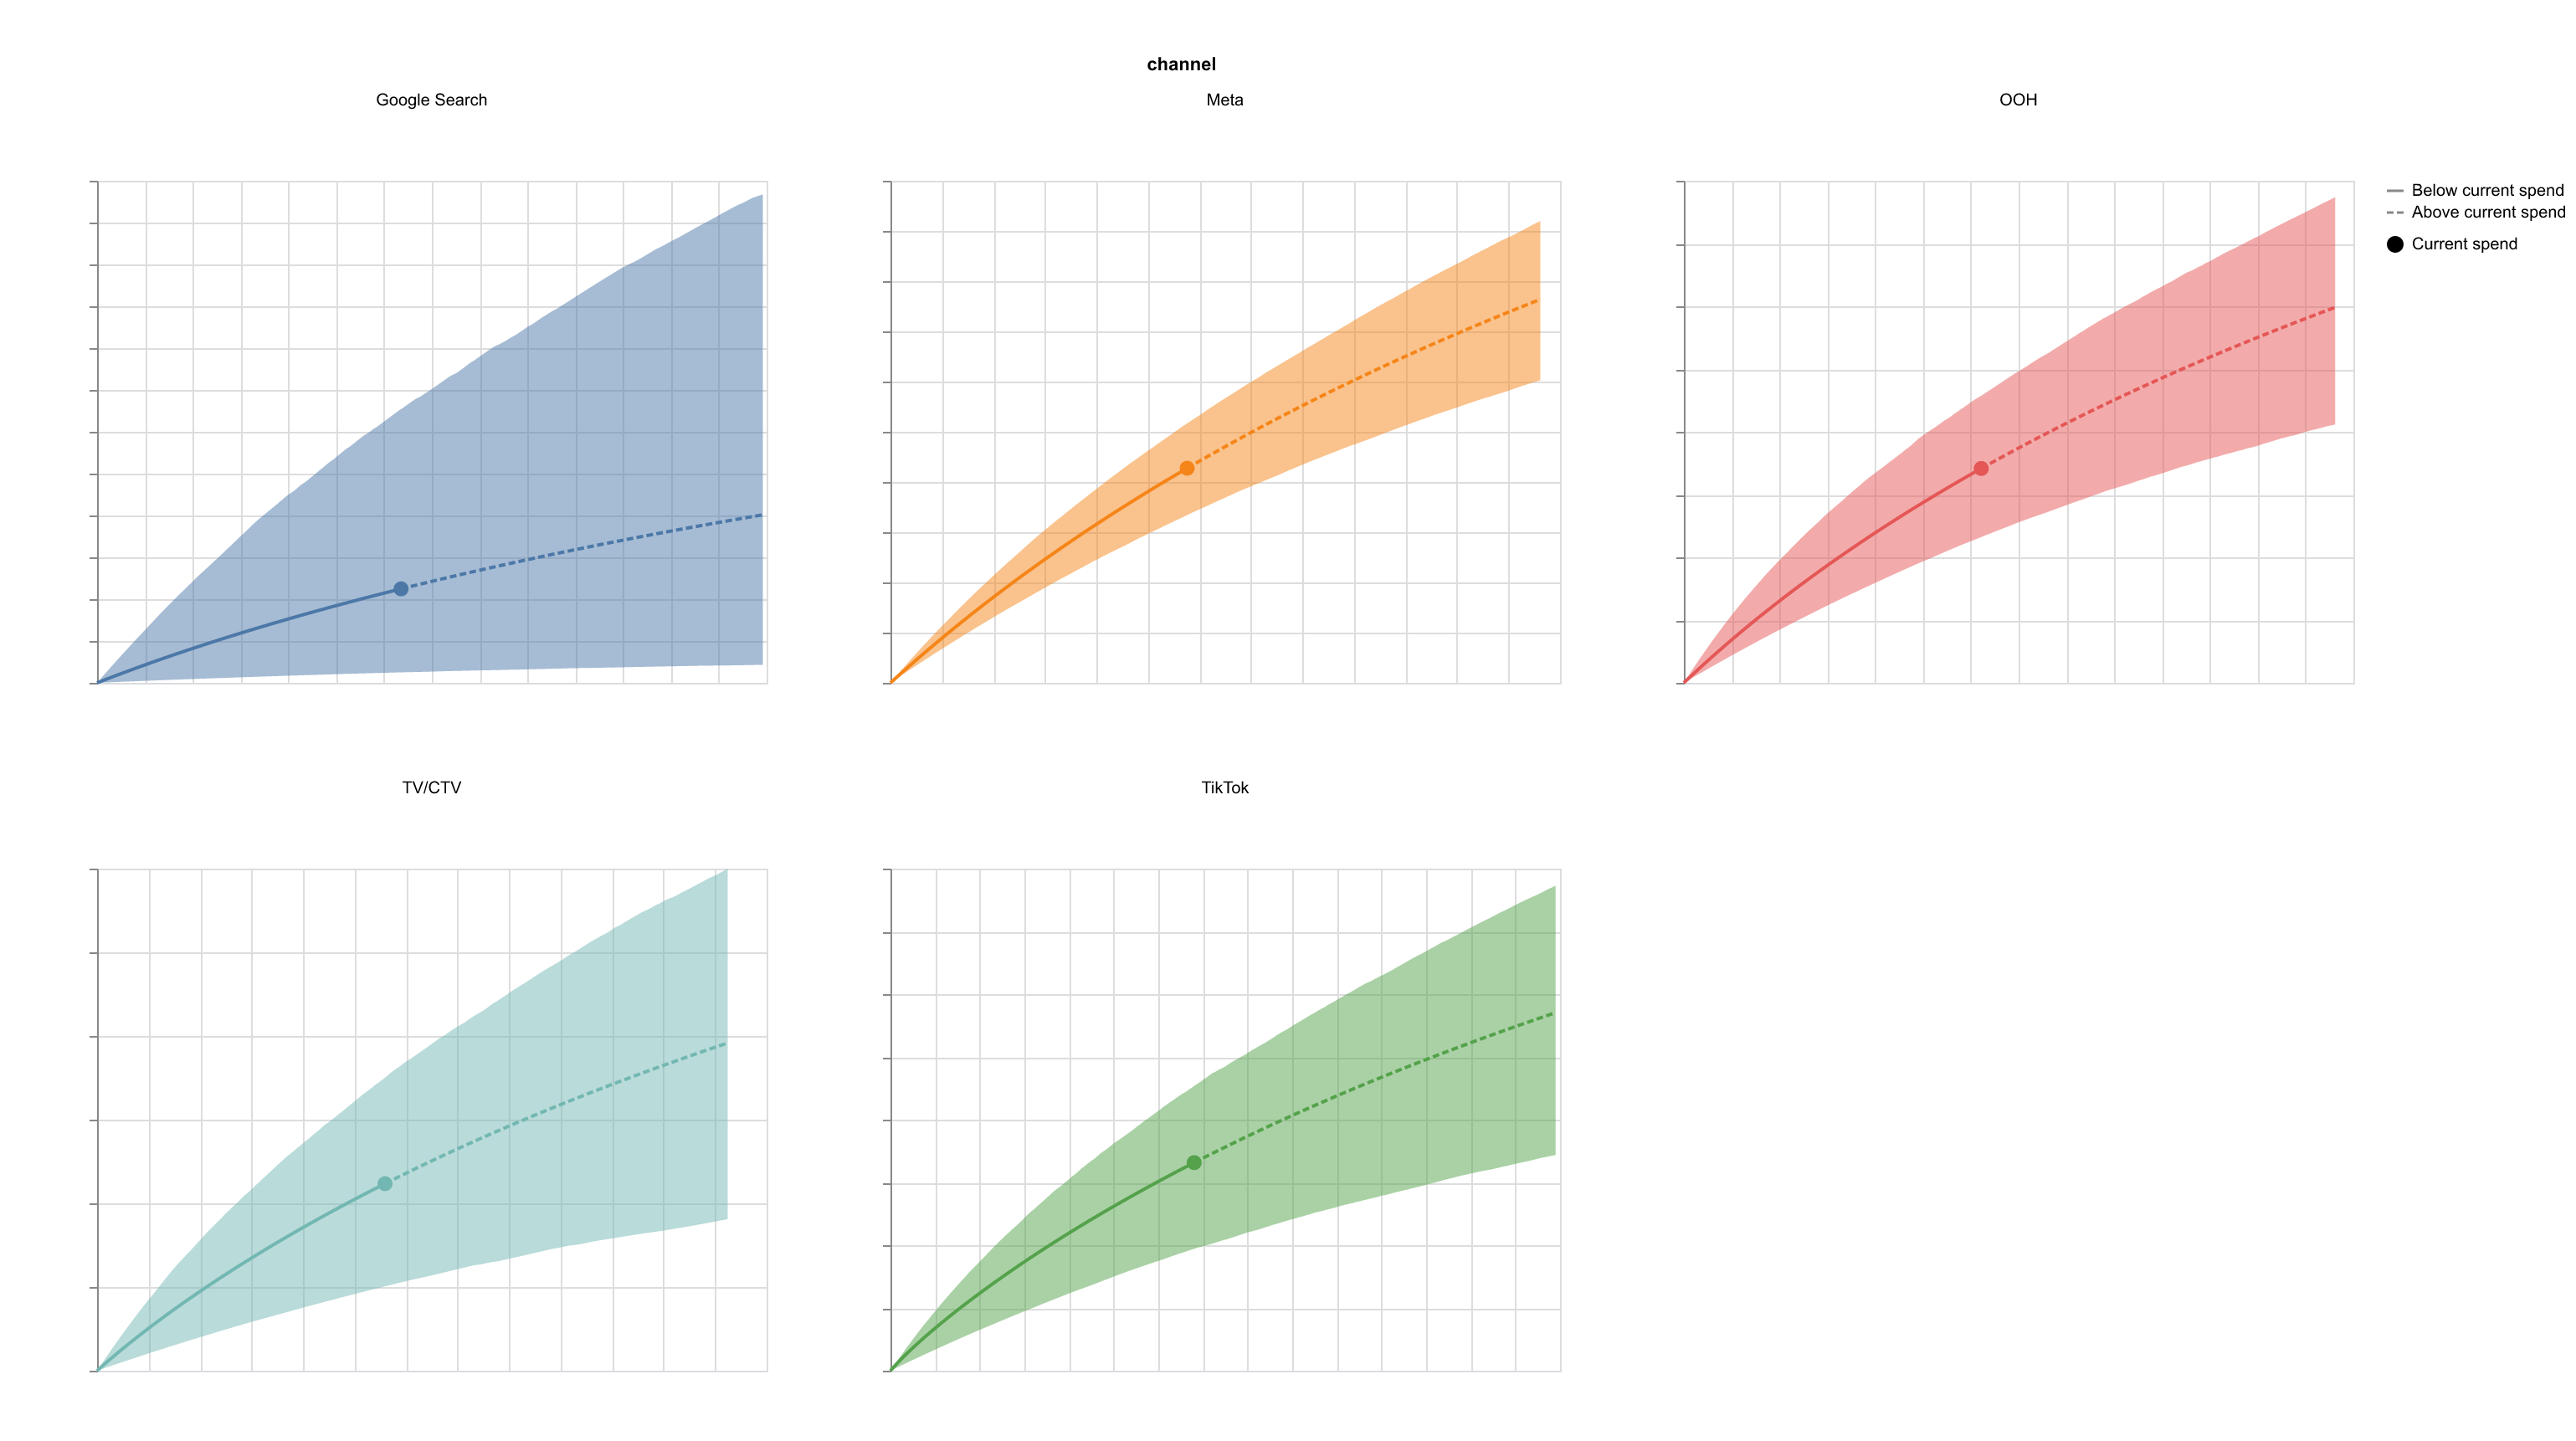

In [17]:
# Response curves: how each channel's incremental effect varies with spend
media_effects = visualizer.MediaEffects(mmm)
media_effects.plot_response_curves()

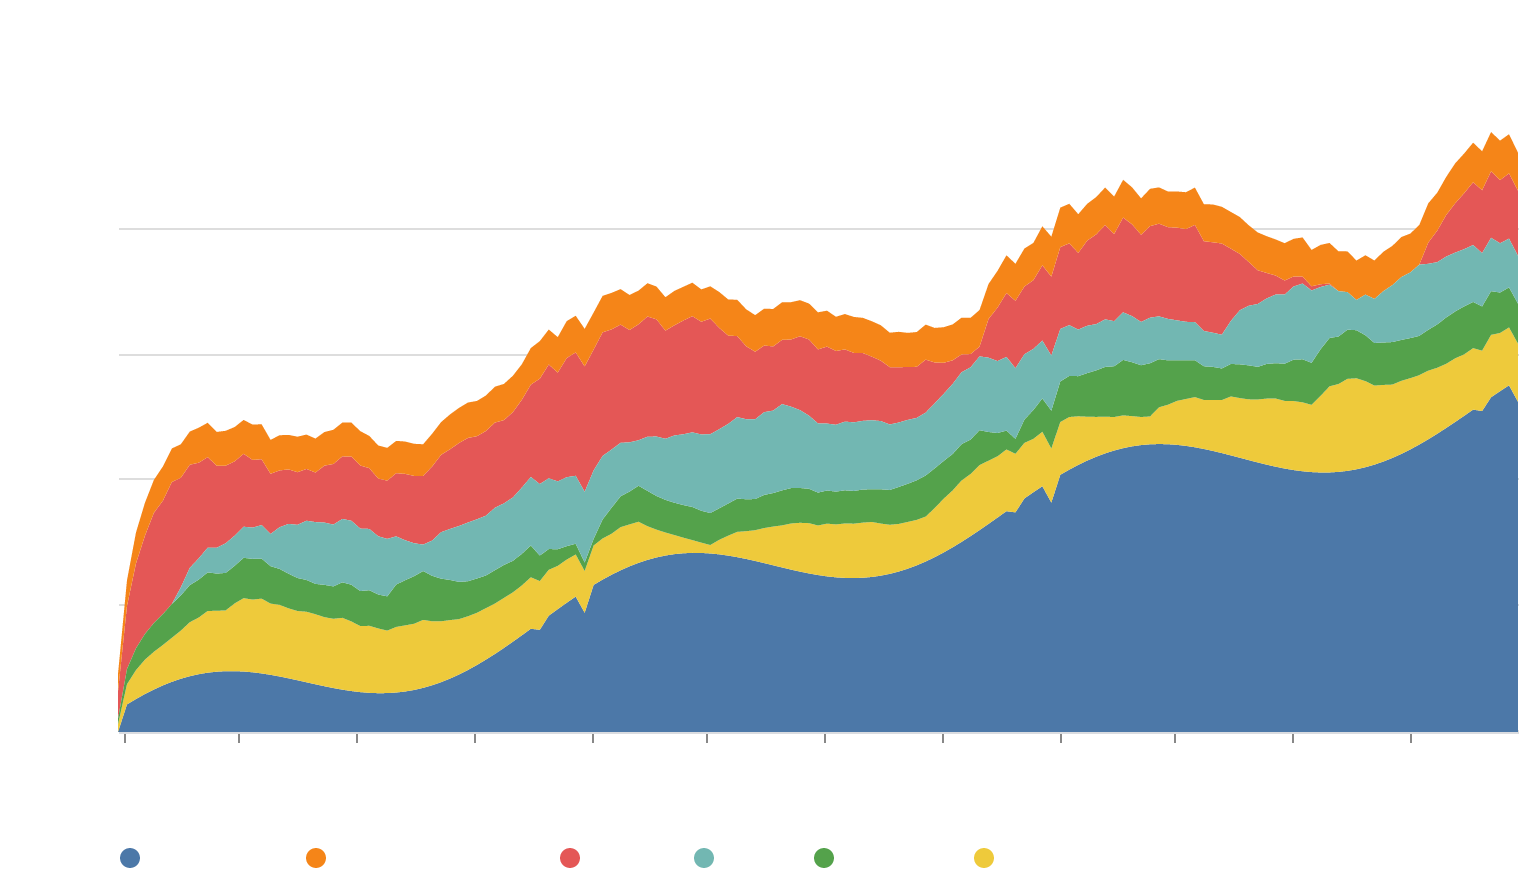

In [18]:
# Media and baseline contribution over time (stacked area)
media_summary.plot_channel_contribution_area_chart()

In [19]:
# Generate an HTML dashboard with all model results
mmm_summarizer = summarizer.Summarizer(mmm)
mmm_summarizer.output_model_results_summary('summary_output.html', filepath='.')

That one `Summarizer` call writes a stakeholder-ready two-page HTML report — model fit, channel contributions, ROI with credible intervals, response curves — with no chart code at all. The copy this notebook produced is published with the book: [summary_output.html](https://marketing-science-in-python.com/notebooks/part6-media-optimization/summary_output.html).

## Step 10: Ground-Truth ROI Comparison

Since we generated the data with PySiMMMulator, we know the **true ROI** for each channel. This lets us directly validate Meridian's posterior estimates — a luxury unavailable with real-world data.

We pull the posterior mean ROI per channel from `get_paid_summary_metrics()` (an xarray Dataset with explicit `channel` and `metric` coordinates), align it to the ground-truth table, and plot true vs. estimated.

What "good recovery" looks like here:

1. **Sign and direction** — every channel's posterior should be on the positive side (Meridian's `roi_m` is LogNormal, so this is automatic) and the rank ordering should roughly match the truth.
2. **Truth inside the credible interval** — for a 90% interval and five channels, we expect *most* channels to contain the true ROAS. Channels where the truth falls outside flag identification weakness, not model failure.
3. **Width is informative** — a wide CI is a signal that the data on its own is not enough to pin the channel down. Section 6.3 turns those wide-CI channels into geo-lift candidates; Section 6.4 and the calibration cell in Step 14 show how the result enters the MMM.

Perfect recovery is not expected. The holdout removes 25% of the KPI signal, channel spends are moderately correlated, and the generator adds observation noise that no model can explain. One channel is expected to fail outright: Google Search runs an always-on budget at nearly constant weekly spend, so the likelihood has almost nothing to say about its coefficient and the posterior comes back close to the prior. That is the demo's whole reason for Sections 6.3 and 6.4.

The ground-truth table now carries two ROI columns, because the generator builds each channel's response curve to hit both. `true_roi` is the average return over all of the channel's spend; `true_marginal_roi` is the return on a one percent increase, the quantity the optimizer works from. On a concave curve the second is always smaller, and how much smaller varies by channel.

      Channel  True ROI  Estimated ROI  90% CI low  90% CI high  True mROI  Estimated mROI  mROI 90% CI low  mROI 90% CI high  Difference
       TV/CTV      4.17          3.998       1.804        6.263      1.800           3.094            1.453             4.734      -0.172
          OOH      6.28          5.492       3.736        7.357      3.500           4.270            2.868             5.592      -0.788
Google Search      0.35          3.534       0.394       10.292      0.213           2.835            0.305             8.283       3.184
         Meta      3.75          7.420       5.800        8.970      2.800           5.959            4.638             7.229       3.670
       TikTok      3.01          4.872       2.854        6.669      0.800           3.638            2.074             4.992       1.862


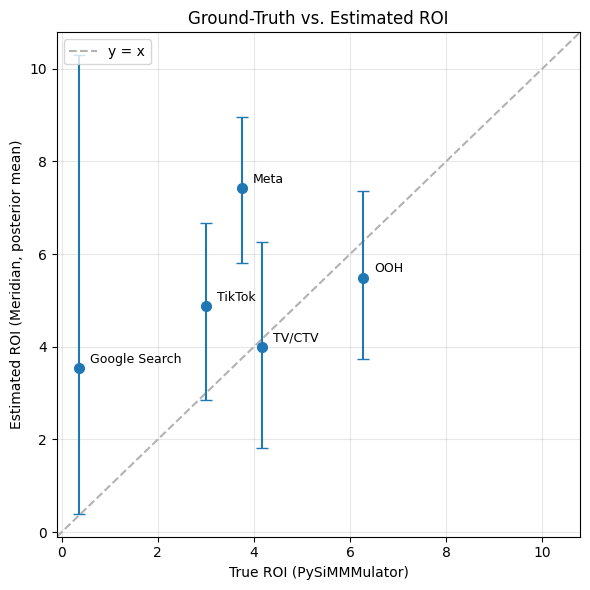

In [20]:
# ---- Extract estimated ROI from Meridian (posterior mean) ----
paid_metrics = media_summary.get_paid_summary_metrics()  # xarray Dataset

# `roi` is a metric coordinate; `mean` lives along the `distribution` dim.
roi_da = paid_metrics["roi"].sel(distribution="posterior")
est_roi_by_channel = {
    ch: float(roi_da.sel(channel=ch, metric="mean").values)
    for ch in channels
}

ci_lo = {ch: float(roi_da.sel(channel=ch, metric="ci_lo").values) for ch in channels}
ci_hi = {ch: float(roi_da.sel(channel=ch, metric="ci_hi").values) for ch in channels}

# ---- Build comparison table ----
true_roi = dict(zip(truth_df["channel"], truth_df["true_roi"]))
true_marginal_roi = dict(zip(truth_df["channel"], truth_df["true_marginal_roi"]))

# The optimizer allocates on marginal return, so recover that too. Meridian's
# mROI is the return on a 1% spend increase (`constants.MROI_FACTOR`).
analyzer_obj = analyzer.Analyzer(mmm)
mroi_draws = analyzer_obj.marginal_roi(incremental_increase=0.01).numpy()

rows = []
for i, ch in enumerate(channels):
    t = true_roi.get(ch, np.nan)
    e = est_roi_by_channel[ch]
    m = mroi_draws[..., i]
    rows.append({
        "Channel": ch,
        "True ROI": round(t, 3),
        "Estimated ROI": round(e, 3),
        "90% CI low": round(ci_lo[ch], 3),
        "90% CI high": round(ci_hi[ch], 3),
        "True mROI": round(true_marginal_roi.get(ch, np.nan), 3),
        "Estimated mROI": round(float(m.mean()), 3),
        "mROI 90% CI low": round(float(np.quantile(m, 0.05)), 3),
        "mROI 90% CI high": round(float(np.quantile(m, 0.95)), 3),
    })

comparison_df = pd.DataFrame(rows)
comparison_df["Difference"] = (comparison_df["Estimated ROI"] - comparison_df["True ROI"]).round(3)
print(comparison_df.to_string(index=False))

# ---- Scatter plot: true vs estimated ----
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    comparison_df["True ROI"],
    comparison_df["Estimated ROI"],
    yerr=[
        comparison_df["Estimated ROI"] - comparison_df["90% CI low"],
        comparison_df["90% CI high"] - comparison_df["Estimated ROI"],
    ],
    fmt="o", markersize=7, capsize=4, zorder=3, color="C0",
)

for _, row in comparison_df.iterrows():
    ax.annotate(
        row["Channel"], (row["True ROI"], row["Estimated ROI"]),
        textcoords="offset points", xytext=(8, 4), fontsize=9,
    )

# 45-degree reference line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0], 0),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, "--", color="gray", alpha=0.6, zorder=1, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True ROI (PySiMMMulator)")
ax.set_ylabel("Estimated ROI (Meridian, posterior mean)")
ax.set_title("Ground-Truth vs. Estimated ROI")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Checkpoint.** Save the fitted model so downstream cells (optimizer, reallocation) can be re-run without re-paying the MCMC cost.

In [21]:
from meridian.schema.serde import meridian_serde
from msbook.paths import chapter_artifacts

_ARTIFACTS = chapter_artifacts(part="6", chapter="sec6-mmm")
_MODEL_PATH = _ARTIFACTS / "mmm_model.binpb"
meridian_serde.save_meridian(mmm, file_path=str(_MODEL_PATH))
# Print the repo-relative location. An absolute path is specific to the machine
# that ran this, and must not land in a published notebook's output.
print(f"Fitted model checkpointed to artifacts/part6/sec6-mmm/{_MODEL_PATH.name}")

Fitted model checkpointed to artifacts/part6/sec6-mmm/mmm_model.binpb


## Step 11: Budget Optimization

Given the fitted response curves, Meridian's `BudgetOptimizer` finds the allocation that maximizes expected revenue under a fixed total budget. By default it uses historical total spend as the budget and constrains each channel to ±30% of its historical allocation.

In [22]:
budget_optimizer = optimizer.BudgetOptimizer(mmm)
optimization_results = budget_optimizer.optimize()

In [23]:
optimization_results.output_optimization_summary(
    "optimization_output.html", filepath="."
)

> **Note.** The dashboard written above is the optimizer's output for the **uncalibrated** model fit (Step 6). It is the §6.2 view of the budget recommendation, before any experimental evidence is layered in. Step 17 reruns the optimizer on the calibrated fit and prints a side-by-side comparison.

In [24]:
# The dashboard is an interactive HTML file (~400 KB of JavaScript). It is not
# embedded in the notebook output: GitHub strips scripts from rendered
# notebooks, so it would show up as a large blank block there. Both dashboards
# sit next to this notebook and are published with the book:
#   https://marketing-science-in-python.com/notebooks/part6-media-optimization/summary_output.html
#   https://marketing-science-in-python.com/notebooks/part6-media-optimization/optimization_output.html
print("Budget-optimization dashboard written to optimization_output.html")

Budget-optimization dashboard written to optimization_output.html


## Step 12: Reallocation Table — From Optimizer Output to Action

The HTML summary above is for a stakeholder audience. For an analyst handing the result to a media planner, we want a single table: for each channel, how much spend the optimizer adds or removes (in dollars and percent), and the lift in expected incremental revenue. This is the artifact you bring to the planning meeting.

In [25]:
nonopt = optimization_results.nonoptimized_data
opt = optimization_results.optimized_data


def _per_channel(da):
    """Reduce an OptimizationResults variable to a 1-D (channel,) array.

    Some Meridian variables (e.g., `roi`, `mroi`) are posterior summaries
    with a `metric` dim (mean, ci_lo, ci_hi); others (e.g., `spend`) are
    already (channel,). Take the `mean` if a `metric` dim is present.
    """
    if "metric" in da.dims:
        return da.sel(metric="mean").values
    return da.values


reallocation = pd.DataFrame({
    "Channel": [str(c) for c in nonopt.channel.values],
    "Current spend ($)":   _per_channel(nonopt.spend),
    "Optimized spend ($)": _per_channel(opt.spend),
    "Δ spend ($)":         _per_channel(opt.spend) - _per_channel(nonopt.spend),
    "Δ spend (%)":         (_per_channel(opt.spend) - _per_channel(nonopt.spend)) / _per_channel(nonopt.spend) * 100.0,
    "Current ROI":         _per_channel(nonopt.roi),
    "Optimized ROI":       _per_channel(opt.roi),
    "Current incremental ($)":   _per_channel(nonopt.incremental_outcome),
    "Optimized incremental ($)": _per_channel(opt.incremental_outcome),
})

reallocation = reallocation.sort_values("Δ spend ($)", ascending=False).reset_index(drop=True)

# Format display
fmt = reallocation.copy()
for c in ["Current spend ($)", "Optimized spend ($)", "Δ spend ($)",
          "Current incremental ($)", "Optimized incremental ($)"]:
    fmt[c] = fmt[c].map(lambda x: f"${x:,.0f}")
fmt["Δ spend (%)"]   = fmt["Δ spend (%)"].map(lambda x: f"{x:+.1f}%")
fmt["Current ROI"]   = fmt["Current ROI"].map(lambda x: f"{x:.2f}")
fmt["Optimized ROI"] = fmt["Optimized ROI"].map(lambda x: f"{x:.2f}")

print(fmt.to_string(index=False))

current_spend  = _per_channel(nonopt.spend)
optimized_spend = _per_channel(opt.spend)
current_inc    = _per_channel(nonopt.incremental_outcome)
optimized_inc  = _per_channel(opt.incremental_outcome)

total_budget = float(current_spend.sum())
total_lift   = float(optimized_inc.sum() - current_inc.sum())
print(f"\nTotal budget held constant at ${total_budget:,.0f}")
print(f"Expected incremental-revenue lift from reallocation: ${total_lift:+,.0f}"
      f"  ({total_lift / float(current_inc.sum()) * 100:+.2f}%)")

      Channel Current spend ($) Optimized spend ($)  Δ spend ($) Δ spend (%) Current ROI Optimized ROI Current incremental ($) Optimized incremental ($)
          OOH      $124,400,000        $161,700,000  $37,300,000      +30.0%        5.49          5.16            $683,219,264              $833,673,088
         Meta      $115,200,000        $149,800,000  $34,600,000      +30.0%        7.42          7.01            $854,819,968            $1,050,459,648
       TikTok      $136,100,000        $135,800,000    $-300,000       -0.2%        4.87          4.88            $663,129,472              $662,034,688
       TV/CTV      $111,800,000         $78,300,000 $-33,500,000      -30.0%        4.00          4.30            $446,946,240              $336,335,456
Google Search      $127,100,000         $89,000,000 $-38,100,000      -30.0%        3.53          3.76            $449,225,216              $334,552,896

Total budget held constant at $614,600,000
Expected incremental-revenue lift from

## Step 13: Credible Interval Guardrail

The reallocation table above prints the optimizer's point estimate. A planner should not act on point estimates alone — wide posteriors mean the model is unsure where the true return sits, and shifting six- or seven-figure budgets on noisy estimates is how MMM programs lose credibility.

Apply the guardrail to **marginal** ROAS, not average ROAS. The optimizer moves the next dollar, so the next dollar's return is the quantity whose uncertainty should decide whether the move is safe.

A simple two-part rule:

1. **Sign certainty.** If the 90% credible interval's lower bound is below zero, the model has not ruled out a negative return for that channel. Treat any reallocation toward it as **hold** — collect more data or run a geo test before moving budget.
2. **Magnitude noise.** Even with a positive sign, very wide intervals mean the model is interpolating without strong identification. We flag relative half-width = (CI upper − CI lower) / (2 × mean) and require it below 0.8 for an **act** call.

This is an illustrative governance rule, not a universal statistical cutoff. Both thresholds are tunable; tighten them for high-stakes decisions, loosen for early exploratory work.

In [26]:
def guardrail_table(mroi_posterior, reallocation_frame, channel_names):
    """Score each channel's marginal-ROAS interval and return the act/hold call."""
    rows = []
    for index, channel in enumerate(channel_names):
        draws = mroi_posterior[..., index]
        mean = float(draws.mean())
        low = float(np.quantile(draws, 0.05))
        high = float(np.quantile(draws, 0.95))
        half_width = (high - low) / (2 * abs(mean))
        rows.append({
            "Channel": channel,
            "Marginal ROAS": mean,
            "90% CI low": low,
            "90% CI high": high,
            "Rel half-width": half_width,
            "Sign-certain": low > 0,
            "Magnitude-tight": half_width < 0.8,
        })
    frame = pd.DataFrame(rows).merge(
        reallocation_frame[["Channel", "Δ spend ($)", "Δ spend (%)"]], on="Channel"
    )

    def _recommendation(row):
        if not row["Sign-certain"]:
            return "HOLD — return sign unclear"
        if not row["Magnitude-tight"]:
            return "HOLD — interval too wide"
        # A move under one percent of current spend is not a reallocation.
        if abs(row["Δ spend (%)"]) < 1.0:
            return "ACT — hold flat"
        if row["Δ spend ($)"] > 0:
            return "ACT — increase spend"
        return "ACT — decrease spend"

    frame["Recommendation"] = frame.apply(_recommendation, axis=1)
    return frame


guardrail = guardrail_table(mroi_draws, reallocation, channels)

display_cols = [
    "Channel", "Marginal ROAS", "90% CI low", "90% CI high",
    "Rel half-width", "Δ spend (%)", "Recommendation",
]
display_fmt = guardrail[display_cols].copy()
for column in ["Marginal ROAS", "90% CI low", "90% CI high", "Rel half-width"]:
    display_fmt[column] = display_fmt[column].map(lambda x: f"{x:.2f}")
display_fmt["Δ spend (%)"] = display_fmt["Δ spend (%)"].map(lambda x: f"{x:+.1f}%")
print(display_fmt.to_string(index=False))

actionable_total = float(
    guardrail.loc[guardrail["Recommendation"].str.startswith("ACT"), "Δ spend ($)"].abs().sum()
)
total_optimizer_move = float(guardrail["Δ spend ($)"].abs().sum())
print(
    f"\n{actionable_total / total_optimizer_move * 100:.0f}% of the optimizer's recommended move "
    f"(${actionable_total:,.0f} of ${total_optimizer_move:,.0f}) passes the guardrail."
)

held = guardrail.loc[guardrail["Recommendation"].str.startswith("HOLD"), "Channel"].tolist()
print(f"Held: {', '.join(held) if held else 'none'}")

      Channel Marginal ROAS 90% CI low 90% CI high Rel half-width Δ spend (%)           Recommendation
       TV/CTV          3.09       1.45        4.73           0.53      -30.0%     ACT — decrease spend
          OOH          4.27       2.87        5.59           0.32      +30.0%     ACT — increase spend
Google Search          2.83       0.31        8.28           1.41      -30.0% HOLD — interval too wide
         Meta          5.96       4.64        7.23           0.22      +30.0%     ACT — increase spend
       TikTok          3.64       2.07        4.99           0.40       -0.2%          ACT — hold flat

74% of the optimizer's recommended move ($105,700,000 of $143,800,000) passes the guardrail.
Held: Google Search


## Step 14: What the Model Predicts for the Test We Are About to Run

Before any experiment exists, ask the model what the experiment will find. Section 6.3 cuts Google Search by 30% for eight weeks; the same policy can be simulated here by scaling Search's exposure and spend in the final eight weeks and reading the revenue difference. Recording that prediction now is what lets the experiment grade the model as well as the channel.

In [27]:
GOOGLE_INDEX = channels.index("Google Search")
media_values = data.media.values
spend_values = data.media_spend.values
time_labels = [str(t) for t in data.time.values]
LAST_EIGHT_WEEKS = time_labels[-8:]


def same_policy_prediction(fitted_model, multiplier=0.70, weeks=8):
    """ROAS of a sustained spend change in the final weeks: revenue moved / spend moved."""
    an = analyzer.Analyzer(fitted_model)
    window = time_labels[-weeks:]
    baseline_outcome = an.incremental_outcome(selected_times=window).numpy()
    new_media = media_values.copy()
    new_spend = spend_values.copy()
    new_media[:, -weeks:, GOOGLE_INDEX] *= multiplier
    new_spend[:, -weeks:, GOOGLE_INDEX] *= multiplier
    changed_outcome = an.incremental_outcome(
        new_data=analyzer.DataTensors(
            media=tf.constant(new_media, dtype=DTYPE),
            media_spend=tf.constant(new_spend, dtype=DTYPE),
        ),
        selected_times=window,
    ).numpy()
    spend_moved = float(spend_values[:, -weeks:, GOOGLE_INDEX].sum() * abs(1.0 - multiplier))
    revenue_moved = baseline_outcome[..., GOOGLE_INDEX] - changed_outcome[..., GOOGLE_INDEX]
    if multiplier > 1.0:
        revenue_moved = -revenue_moved
    return revenue_moved / spend_moved, spend_moved


pretest_draws, pretest_spend = same_policy_prediction(mmm)
print(f"Policy: cut Google Search 30% for the final 8 weeks (${pretest_spend:,.0f} removed)")
print(f"Model's predicted ROAS of that cut: {pretest_draws.mean():.3f}  "
      f"90% CI [{np.quantile(pretest_draws, 0.05):.3f}, {np.quantile(pretest_draws, 0.95):.3f}]")
print(f"True value planted in the data:     "
      f"{float(truth_df.set_index('channel').loc['Google Search', 'true_pullback_roas_8w']):.3f}")
print()
print("Tested markets' share of national Search spend over the same eight weeks:")
national_eight_week_search = float(df["google_spend"].tail(8).sum())
tested_markets_spend = 1_406_355.0  # baseline spend in the eight test markets, from sec6.3
print(f"  national ${national_eight_week_search:,.0f}; tested markets ${tested_markets_spend:,.0f} "
      f"({tested_markets_spend / national_eight_week_search:.1%})")

Policy: cut Google Search 30% for the final 8 weeks ($2,117,362 removed)
Model's predicted ROAS of that cut: 2.542  90% CI [0.281, 7.206]
True value planted in the data:     0.200

Tested markets' share of national Search spend over the same eight weeks:
  national $7,057,873; tested markets $1,406,355 (19.9%)


## Step 15: From Geo-Lift Estimate to Calibrated Prior

Section 6.3's evidence package: a 30% cut in eight matched markets over eight weeks gave up **0.200** of revenue per dollar removed, with clustered standard error **0.075**.

That number is a *marginal* quantity measured at today's operating point. Meridian's `roi_m` prior describes *average* ROAS, the return on all of a channel's spend measured from zero. Putting a marginal measurement into an average prior anchors the wrong end of the curve, so we set `media_prior_type="mroi"` and place the evidence on `mroi_m` instead. Meridian defines mROI as the return on a one percent spend increase (`constants.MROI_FACTOR`), which is close to but not identical to the 30% block the experiment moved, so three translations apply:

1. **Contrast.** The experiment averaged the curve between 70% and 100% of spend; the prior describes the slope at 100%. The model's own curve gives the ratio between them.
2. **Duration.** An eight-week window captures only part of a channel's carryover. Search's half-life is one week, so the capture is essentially complete and the factor is near 1; for a six-week half-life channel it would not be.
3. **Scale and recency.** The test moved spend in eight markets for eight weeks; the parameter describes the channel nationally across the whole modeled period. That gap adds width, not a shift. Recency adds almost nothing here because the experiment runs six weeks after the modeled period ends; a test a year old would add materially more.

The notebook also fits the *wrong* version — the same 0.200 placed on `roi_m` — so Section 6.4 can show what pasting a marginal number into an average prior does.

In [28]:
EXPERIMENT_ROAS = 0.200
# Section 6.3 reports two defensible widths for the same point estimate: 0.075
# clustering on the 16 markets, 0.110 clustering on the 8 matched pairs the
# design actually randomized. The narrower one is pre-specified; the wider one
# is carried through to the end so the guardrail verdict can be checked at both.
EXPERIMENT_SE = 0.075
EXPERIMENT_SE_PAIR_CLUSTERED = 0.110


def lognormal_from_mean_std(mean, std):
    """Meridian ships this as `prior_distribution.lognormal_dist_from_mean_std`;
    the arithmetic is short enough to show once."""
    variance = std ** 2
    sigma_squared = np.log(1.0 + variance / mean ** 2)
    return np.log(mean) - sigma_squared / 2.0, np.sqrt(sigma_squared)


# Meridian's documented calibration adjustments. Each is a pure function so the
# test suite can check it at the boundaries instead of trusting a printed number.
def adstock_capture_proportion(decay, window_weeks, max_lag):
    """Share of a channel's carryover weights that fall inside the test window."""
    inside = sum(decay ** lag for lag in range(window_weeks))
    modeled = sum(decay ** lag for lag in range(max_lag + 1))
    return inside / modeled


def spend_rate_ratio(experiment_spend, experiment_weeks, channel_spend, channel_weeks):
    """Ratio of average daily spend rates, smaller over larger, so it lands in (0, 1]."""
    experiment_rate = experiment_spend / (experiment_weeks * 7.0)
    channel_rate = channel_spend / (channel_weeks * 7.0)
    return min(experiment_rate, channel_rate) / max(experiment_rate, channel_rate)


def tau_spend(ratio):
    """A test that covers the channel's whole spend rate adds nothing; a small
    one adds a lot. Note the direction: the penalty grows as the ratio falls."""
    return (1.0 - ratio) / ratio


def tau_recency(weeks_since_experiment, half_life_weeks=52.0):
    """Old evidence is discounted. An experiment that runs after the modeled
    period ends is not stale, so it carries no recency penalty."""
    if weeks_since_experiment <= 0:
        return 0.0
    decay = 0.5 ** (weeks_since_experiment / half_life_weeks)
    return (1.0 - decay) / decay


def tau_duration(capture_proportion):
    """A window that misses carryover is less informative about the full effect."""
    return max((1.0 - capture_proportion) / capture_proportion, 0.0)


def calibrated_prior_moments(estimate, standard_error, capture_proportion, taus):
    """Google's shape: duration scales the centre, every tau widens the prior."""
    centre = estimate / capture_proportion
    width = standard_error * np.sqrt(1.0 + sum(taus))
    return centre, width


# (1) Duration. Use the half-life the model assumes for lower-funnel channels,
#     not the generator's planted value: a real project has the assumption, not
#     the truth. It is the one adjustment that moves the centre.
search_prior_decay = 0.5 ** (1.0 / half_life_weeks[channel_funnel["Google Search"]])
duration_capture = adstock_capture_proportion(search_prior_decay, 8, 12)

# (2) Spend scale. The test moved a fifth of the channel's daily spend rate.
national_search_spend = float(df["google_spend"].sum())
spend_ratio = spend_rate_ratio(
    experiment_spend=tested_markets_spend,
    experiment_weeks=8,
    channel_spend=national_search_spend,
    channel_weeks=n_times,
)

# (3) Recency. The experiment ends after the modeled period, so it is not stale.
weeks_after_model_end = -6.0

# (4) Contrast. Not one of Google's adjustments: the experiment averaged the
#     curve between 70% and 100% of spend while the prior describes the slope at
#     100%. The model has an opinion about that gap, but the opinion comes from
#     the fit the experiment exists to correct, so it widens the prior instead of
#     moving it. This term is ours, and it is small next to the spend penalty.
model_mroi_search = float(mroi_draws[..., GOOGLE_INDEX].mean())
full_period_pullback, _ = same_policy_prediction(mmm, multiplier=0.70, weeks=len(time_labels))
contrast_gap = abs(1.0 - model_mroi_search / float(full_period_pullback.mean()))

taus = {
    "spend": tau_spend(spend_ratio),
    "recency": tau_recency(weeks_after_model_end),
    "duration": tau_duration(duration_capture),
    "contrast (ours, not Google's)": contrast_gap ** 2,
}
mroi_center, mroi_se = calibrated_prior_moments(
    EXPERIMENT_ROAS, EXPERIMENT_SE, duration_capture, taus.values()
)
mroi_mu, mroi_sigma = lognormal_from_mean_std(mroi_center, mroi_se)

# The same translation applied to the conservative width.
_, mroi_se_wide = calibrated_prior_moments(
    EXPERIMENT_ROAS, EXPERIMENT_SE_PAIR_CLUSTERED, duration_capture, taus.values()
)
mroi_mu_wide, mroi_sigma_wide = lognormal_from_mean_std(mroi_center, mroi_se_wide)

print(f"Experiment: ROAS {EXPERIMENT_ROAS:.3f}, SE {EXPERIMENT_SE:.3f}")
print(f"  adstock capture in 8 weeks : {duration_capture:.4f}  [scales the centre]")
print(f"  spend rate ratio           : {spend_ratio:.4f}")
for name, value in taus.items():
    print(f"    tau {name:28s}: {value:.4f}")
print(f"  total variance inflation   : {1.0 + sum(taus.values()):.4f}")
print(f"  -> mroi_m centre {mroi_center:.4f}, SE {mroi_se:.4f}")
print(f"  -> LogNormal(loc={mroi_mu:.4f}, scale={mroi_sigma:.4f})")
print(f"  pair-clustered width: SE {mroi_se_wide:.4f} "
      f"-> LogNormal(loc={mroi_mu_wide:.4f}, scale={mroi_sigma_wide:.4f})")

# Weak marginal-ROI prior for the four uncalibrated channels. It is the same
# weak belief as §6.2's roi_m prior, restated on the marginal scale: on this
# panel the posterior mROI runs about half the posterior ROI, so the location
# shifts by ln(0.5). A diffuse marginal prior is not a safe default here — with
# a saturating curve it leaves average ROI unbounded above, and the uncalibrated
# channels' intervals blow up.
WEAK_MROI_MU = 0.2 + np.log(0.5)
WEAK_MROI_SIGMA = 0.9

mroi_mu_array = np.full(len(channels), WEAK_MROI_MU)
mroi_sigma_array = np.full(len(channels), WEAK_MROI_SIGMA)
mroi_mu_array[GOOGLE_INDEX] = mroi_mu
mroi_sigma_array[GOOGLE_INDEX] = mroi_sigma

mroi_mu_wide_array = np.full(len(channels), WEAK_MROI_MU)
mroi_sigma_wide_array = np.full(len(channels), WEAK_MROI_SIGMA)
mroi_mu_wide_array[GOOGLE_INDEX] = mroi_mu_wide
mroi_sigma_wide_array[GOOGLE_INDEX] = mroi_sigma_wide

# The mistake, kept so §6.4 can show it: the same evidence, at the same width,
# on an average-ROI prior instead of a marginal one. Using the identical center
# and SE is what makes the comparison about the estimand and nothing else.
roi_mu, roi_sigma = lognormal_from_mean_std(mroi_center, mroi_se)
roi_mu_array = np.full(len(channels), 0.20)
roi_sigma_array = np.full(len(channels), 0.90)
roi_mu_array[GOOGLE_INDEX] = roi_mu
roi_sigma_array[GOOGLE_INDEX] = roi_sigma

print()
print(pd.DataFrame({
    "Channel": channels,
    "mroi_mu": mroi_mu_array,
    "mroi_sigma": mroi_sigma_array,
    "Source": [
        "geo experiment" if i == GOOGLE_INDEX else "weakly informative"
        for i in range(len(channels))
    ],
}).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Experiment: ROAS 0.200, SE 0.075
  adstock capture in 8 weeks : 0.9962  [scales the centre]
  spend rate ratio           : 0.2171
    tau spend                       : 3.6064
    tau recency                     : 0.0000
    tau duration                    : 0.0038
    tau contrast (ours, not Google's): 0.0034
  total variance inflation   : 4.6136
  -> mroi_m centre 0.2008, SE 0.1611
  -> LogNormal(loc=-1.8542, scale=0.7050)
  pair-clustered width: SE 0.2363 -> LogNormal(loc=-2.0403, scale=0.9323)

      Channel  mroi_mu  mroi_sigma             Source
       TV/CTV   -0.493       0.900 weakly informative
          OOH   -0.493       0.900 weakly informative
Google Search   -1.854       0.705     geo experiment
         Meta   -0.493       0.900 weakly informative
       TikTok   -0.493       0.900 weakly informative


## Step 16: Three Refits

Comparing one calibrated fit against Section 6.2 would mix two changes: switching the prior from average to marginal ROI, and adding the experiment. So fit three models.

1. **Control** — every channel on a weak *marginal* prior, no experiment. This is the "before" column: it isolates the parameterization change.
2. **Calibrated** — the same, with Search's marginal prior set from the experiment. The difference between this and the control is the experiment alone.
3. **Average-prior calibration** — the experiment's number placed on `roi_m` instead, at the same centre and width. This is the mistake Section 6.4 warns about, and using identical moments is what makes the comparison about the estimand rather than the arithmetic.
4. **Calibrated at the pair-clustered width** — the same evidence carried through Section 6.3's conservative standard error, so the guardrail verdict can be read at both defensible widths.

Each is a fresh MCMC pass and adds roughly the same wall-clock time as Step 6 on CPU.

In [29]:
def build_prior(roi_kind, loc_array, scale_array):
    """One prior builder for both parameterizations; alpha_m and ec_m never change."""
    shared = dict(
        alpha_m=tfp.distributions.TruncatedNormal(
            loc=alpha_loc, scale=tf.constant(0.1, dtype=DTYPE),
            low=tf.constant(0.0, dtype=DTYPE), high=tf.constant(1.0, dtype=DTYPE),
            name=constants.ALPHA_M,
        ),
        ec_m=tfp.distributions.TruncatedNormal(
            loc=tf.constant(5.0, dtype=DTYPE), scale=tf.constant(2.0, dtype=DTYPE),
            low=tf.constant(0.1, dtype=DTYPE), high=tf.constant(30.0, dtype=DTYPE),
            name=constants.EC_M,
        ),
    )
    name = constants.MROI_M if roi_kind == "mroi" else constants.ROI_M
    distribution = tfp.distributions.LogNormal(
        loc=tf.constant(loc_array, dtype=DTYPE),
        scale=tf.constant(scale_array, dtype=DTYPE),
        name=name,
    )
    key = "mroi_m" if roi_kind == "mroi" else "roi_m"
    return prior_distribution.PriorDistribution(**{key: distribution}, **shared)


def fit_variant(roi_kind, loc_array, scale_array, label):
    fitted = model.Meridian(
        input_data=data,
        model_spec=spec.ModelSpec(
            prior=build_prior(roi_kind, loc_array, scale_array),
            media_prior_type=roi_kind,
            max_lag=12,
            adstock_decay_spec="geometric",
            holdout_id=holdout_id,
        ),
    )
    fitted.sample_prior(500)
    fitted.sample_posterior(n_chains=4, n_adapt=500, n_burnin=500, n_keep=1000, seed=SEED)
    print(f"{label} fit complete.")
    return fitted


weak_mroi_mu = np.full(len(channels), WEAK_MROI_MU)
weak_mroi_sigma = np.full(len(channels), WEAK_MROI_SIGMA)

mmm_control = fit_variant("mroi", weak_mroi_mu, weak_mroi_sigma, "Control (weak marginal prior)")
mmm_calib = fit_variant("mroi", mroi_mu_array, mroi_sigma_array, "Calibrated (marginal prior)")
mmm_avg_prior = fit_variant("roi", roi_mu_array, roi_sigma_array, "Average-prior calibration")
mmm_calib_wide = fit_variant("mroi", mroi_mu_wide_array, mroi_sigma_wide_array,
                             "Calibrated at the pair-clustered width")

2026-09-02 09:17:06.199573: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Control (weak marginal prior) fit complete.


2026-09-02 09:19:34.831012: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Calibrated (marginal prior) fit complete.


2026-09-02 09:21:57.152198: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Average-prior calibration fit complete.


2026-09-02 09:23:10.948415: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Calibrated at the pair-clustered width fit complete.


## Step 17: What Changed

The payoff. Line the three fits up against Section 6.2 and the truth, and ask what calibration actually moved.

In [30]:
truth_row = truth_df.set_index("channel").loc["Google Search"]


def search_summary(fitted_model, label):
    an = analyzer.Analyzer(fitted_model)
    roi_draws = an.roi().numpy()[..., GOOGLE_INDEX]
    marginal_draws = an.marginal_roi(incremental_increase=0.01).numpy()[..., GOOGLE_INDEX]
    policy_draws, _ = same_policy_prediction(fitted_model)
    half_width = (
        (np.quantile(marginal_draws, 0.95) - np.quantile(marginal_draws, 0.05))
        / (2 * abs(marginal_draws.mean()))
    )
    return {
        "Fit": label,
        "Average ROAS": f"{roi_draws.mean():.3f} [{np.quantile(roi_draws, 0.05):.2f}, "
                        f"{np.quantile(roi_draws, 0.95):.2f}]",
        "Marginal ROAS": f"{marginal_draws.mean():.3f} [{np.quantile(marginal_draws, 0.05):.2f}, "
                         f"{np.quantile(marginal_draws, 0.95):.2f}]",
        "Rel half-width": f"{half_width:.2f}",
        "Guardrail": "ACT" if half_width < 0.8 else "HOLD",
        "Predicts the tested cut": f"{policy_draws.mean():.3f} "
                                   f"[{np.quantile(policy_draws, 0.05):.2f}, "
                                   f"{np.quantile(policy_draws, 0.95):.2f}]",
    }


what_changed = pd.DataFrame([
    search_summary(mmm, "6.2 reference (weak average prior)"),
    search_summary(mmm_control, "Before: control (weak marginal prior)"),
    search_summary(mmm_calib, "After: calibrated on the experiment"),
    search_summary(mmm_calib_wide, "After, pair-clustered width"),
    search_summary(mmm_avg_prior, "Mistake: experiment on the average prior"),
])
print("Google Search across the four fits")
print(what_changed.to_string(index=False))
print()
print(f"Truth: average {float(truth_row['true_roi']):.3f}, "
      f"marginal {float(truth_row['true_marginal_roi']):.3f}, "
      f"30% cut over 8 weeks {float(truth_row['true_pullback_roas_8w']):.3f}")
print(f"Experiment measured {EXPERIMENT_ROAS:.3f} (SE {EXPERIMENT_SE:.3f})")

Google Search across the four fits
                                     Fit        Average ROAS      Marginal ROAS Rel half-width Guardrail Predicts the tested cut
      6.2 reference (weak average prior) 3.534 [0.39, 10.29] 2.835 [0.31, 8.28]           1.41      HOLD      2.542 [0.28, 7.21]
   Before: control (weak marginal prior)  2.550 [0.21, 9.25] 1.760 [0.17, 6.36]           1.76      HOLD      1.573 [0.15, 5.52]
     After: calibrated on the experiment  0.273 [0.06, 0.71] 0.215 [0.05, 0.54]           1.13      HOLD      0.196 [0.05, 0.49]
             After, pair-clustered width  0.295 [0.04, 0.93] 0.231 [0.03, 0.71]           1.46      HOLD      0.211 [0.03, 0.64]
Mistake: experiment on the average prior  0.212 [0.05, 0.54] 0.172 [0.04, 0.44]           1.18      HOLD      0.156 [0.04, 0.40]

Truth: average 0.350, marginal 0.213, 30% cut over 8 weeks 0.200
Experiment measured 0.200 (SE 0.075)


## Step 18: Re-Optimize from Each Fit

The interval moved. Did the recommendation? Run the optimizer against the control and the calibrated fit and compare both with Section 6.2's allocation.

In [31]:
def allocation_of(fitted_model):
    result = optimizer.BudgetOptimizer(fitted_model).optimize()
    nonopt, opt = result.nonoptimized_data, result.optimized_data
    reduce = lambda da: da.sel(metric="mean").values if "metric" in da.dims else da.values
    current, optimized = reduce(nonopt.spend), reduce(opt.spend)
    return pd.Series(
        (optimized - current) / current * 100.0,
        index=[str(c) for c in nonopt.channel.values],
    )


allocations = pd.DataFrame({
    "6.2 reference": allocation_of(mmm),
    "Before (control)": allocation_of(mmm_control),
    "After (calibrated)": allocation_of(mmm_calib),
})
print("Optimizer move by channel (% of current spend, ±30% constraint)")
print(allocations.to_string(float_format=lambda x: f"{x:+.1f}%"))
print()
print("Calibration changes what the model knows, not where the optimizer points:")
print("Search sits at the constraint floor in every column. What moves is the")
print("estimate, onto the evidence, and the interval around it; the guardrail's")
print("verdict does not change, because the width that is left comes from")
print("translating eight markets to the country rather than from the measurement.")

Optimizer move by channel (% of current spend, ±30% constraint)
               6.2 reference  Before (control)  After (calibrated)
TV/CTV                -30.0%            -15.4%              -15.7%
OOH                   +30.0%            +30.0%              +30.0%
Google Search         -30.0%            -30.0%              -30.0%
Meta                  +30.0%            +30.0%              +30.0%
TikTok                 -0.2%            -12.2%              -12.0%

Calibration changes what the model knows, not where the optimizer points:
Search sits at the constraint floor in every column. What moves is the
estimate, onto the evidence, and the interval around it; the guardrail's
verdict does not change, because the width that is left comes from
translating eight markets to the country rather than from the measurement.


## Step 19: What This Demo Proves (and Does Not)

This notebook covers a complete MMM workflow end-to-end. Before adopting any number it produces in a real planning conversation, anchor on what the demo can and cannot show.

**Proves:**

- A Bayesian MMM workflow runs cleanly from data through identifiability check, fit, diagnostics, ROI with credible intervals, optimizer, planner-ready reallocation table, decision guardrail, calibration prior construction, refit, and re-optimize.
- Random-holdout R² is a sensible generalization check when the data does not contain regime shifts inside the holdout.
- The §6.4 calibration loop repairs an under-identified channel: Google Search's marginal posterior tightens onto the experimental evidence and its guardrail verdict flips from hold to act, with no meaningful disturbance to the other four channels.
- Calibration changes confidence rather than direction: Search sits at the optimizer's constraint floor before and after, and what moves is the interval around its marginal return.

**Does not prove:**

- Production-MMM accuracy on real data. The dataset is **synthetic** (generated by PySiMMMulator, then rebuilt through adstock and Hill saturation) with known ground-truth response curves; recovery against truth is only available because we chose those truths.
- That random-holdout R² is what production would see. The holdout here is a **random week-level sample** — an interpolation check, close to a best case. A trailing-block holdout on the same data collapses out-of-sample R² to roughly 0.11; production validation should report both.
- That calibration always works. Our experiment lands close to the planted truth by construction. In practice a geo test can be noisy, negative, or measured on an estimand the model cannot host, and §6.4 explains why it should not be forced into an incompatible positive-only prior.
- That the optimizer's reallocation is safe to act on. The optimizer ignores **business constraints**: contractual minimums, channel capacity, contractual lockouts, seasonal flighting, geo-level effects, and inventory feasibility are all outside the model. Treat the output as a principled starting point and pass it through the credible-interval guardrail and a planning conversation before committing budget.
- On production data, expect out-of-sample R² in the 0.6–0.7 range and many more channels failing the guardrail. That is the regime §6.4 says calibration is most valuable in.

## Step 20: Save the Models

Persist three fits as binary protobufs: the Section 6.2 reference, the control, and the calibrated model. The figures and the artifact tests all compare calibrated against control, because that pair isolates the experiment from the change of parameterization. The average-prior counterexample is not saved; it exists only to be printed once.

In [32]:
from meridian.schema.serde import meridian_serde
from msbook.paths import chapter_artifacts

_ARTIFACTS = chapter_artifacts(part="6", chapter="sec6-mmm")
_UNCAL_PATH   = _ARTIFACTS / "mmm_model.binpb"
_CONTROL_PATH = _ARTIFACTS / "mmm_model_control.binpb"
_CAL_PATH     = _ARTIFACTS / "mmm_model_calibrated.binpb"
meridian_serde.save_meridian(mmm,         file_path=str(_UNCAL_PATH))
meridian_serde.save_meridian(mmm_control, file_path=str(_CONTROL_PATH))
meridian_serde.save_meridian(mmm_calib,   file_path=str(_CAL_PATH))
print(f"Saved {_UNCAL_PATH.name}, {_CONTROL_PATH.name} and {_CAL_PATH.name}.")

Saved mmm_model.binpb, mmm_model_control.binpb and mmm_model_calibrated.binpb.
